# CU-BEMS Smart Building Energy — LSTM vs XGBoost Comparative Study
**Target:** `Total_kW` (30-min aggregated building load across all floors)

## 1. Imports & Configuration

In [27]:
import warnings
warnings.filterwarnings('ignore')

import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import Image, display
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error)
from sklearn.model_selection import TimeSeriesSplit

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from xgboost import XGBRegressor
import joblib

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 300, 'font.size': 11})


In [28]:
# CONFIGURATION — adjust paths/hyperparameters
DATA_DIR       = '../CU-BEMS smart building energy and IAQ dataset'
TARGET         = 'Total_kW'

# Sequence length (96 steps × 30 min = 48-hour lookback)
SEQ_LENGTH     = 96

# Lag steps (in 30-min intervals)
LAGS           = [1, 2, 48, 336]        # 30 min, 1 hr, 1 day, 1 week

# Rolling window sizes (in 30-min intervals)
ROLL_WINDOWS   = [4, 8, 48]             # 2 hr, 4 hr, 24 hr

# NaN interpolation limit per sensor (in raw 1-min samples)
INTERP_LIMIT   = 60                     # fill gaps up to 60 minutes

# Maximum fraction of kW sensors that can be missing before
# the row is marked invalid (NaN) instead of zero-padded
NAN_FRAC_THRESH = 0.5

# Cross-validation
N_FOLDS        = 3

# Train/Val/Test split ratios
SPLIT_TRAIN    = 0.70
SPLIT_VAL      = 0.85                   # val = 0.70–0.85, test = 0.85–1.00

# LSTM hyperparameters
LSTM_EPOCHS    = 100
LSTM_BATCH     = 64
LSTM_PATIENCE  = 15

# XGBoost hyperparameters
XGB_N_EST      = 1000
XGB_LR         = 0.05
XGB_DEPTH      = 6
XGB_EARLY_STOP = 50

# Set RETRAIN_LSTM / RETRAIN_XGB to False to skip retraining.
MODEL_DIR        = '../saved_models'
LSTM_MODEL_PATH  = os.path.join(MODEL_DIR, 'lstm_final.keras')
XGB_MODEL_PATH   = os.path.join(MODEL_DIR, 'xgb_final.json')
SCALER_X_PATH    = os.path.join(MODEL_DIR, 'scaler_X.pkl')
SCALER_Y_PATH    = os.path.join(MODEL_DIR, 'scaler_y.pkl')

RETRAIN_LSTM     = False   # ← set False to load saved LSTM instead of retraining
RETRAIN_XGB      = False   # ← set False to load saved XGBoost instead of retraining

## 2. Data Loading — Fixed NaN Handling

In [29]:
def load_floor(fpath, interp_limit=INTERP_LIMIT, nan_thresh=NAN_FRAC_THRESH):

    df = pd.read_csv(fpath)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date').sort_index()

    kw_cols   = [c for c in df.columns if '(kW)'   in c]
    temp_cols = [c for c in df.columns if '(degC)' in c]
    rh_cols   = [c for c in df.columns if '(RH%)'  in c]
    lux_cols  = [c for c in df.columns if '(lux)'  in c]

    all_sensor_cols = kw_cols + temp_cols + rh_cols + lux_cols

    # Step 1 — interpolate short gaps per sensor (time-aware)
    for col in all_sensor_cols:
        df[col] = df[col].interpolate(method='time', limit=interp_limit)

    # Step 2 — flag rows with too many kW sensors still missing
    if kw_cols:
        nan_frac = df[kw_cols].isnull().mean(axis=1)
        kw_sum = df[kw_cols].sum(axis=1, skipna=True).where(nan_frac < nan_thresh)
    else:
        kw_sum = pd.Series(0.0, index=df.index)

    # Step 3 — record which rows still have ANY IAQ sensor NaN after interpolation
    iaq_cols = temp_cols + rh_cols + lux_cols
    if iaq_cols:
        iaq_still_nan = df[iaq_cols].isnull().any(axis=1).astype(int)
    else:
        iaq_still_nan = pd.Series(0, index=df.index)

    result = pd.DataFrame(index=df.index)
    result['Total_kW']      = kw_sum
    result['avg_temp']      = df[temp_cols].mean(axis=1, skipna=True) if temp_cols else np.nan
    result['avg_rh']        = df[rh_cols  ].mean(axis=1, skipna=True) if rh_cols   else np.nan
    result['avg_lux']       = df[lux_cols ].mean(axis=1, skipna=True) if lux_cols  else np.nan
    result['iaq_nan_flag']  = iaq_still_nan   # 1 = at least one IAQ sensor was NaN

    return result


print('Loading floors...')
floor_files = sorted(glob.glob(f'{DATA_DIR}/*.csv'))
if not floor_files:
    raise FileNotFoundError(
        f'No CSV files found in: {DATA_DIR}\n'
        f'Make sure the dataset folder is in the same directory as this notebook.'
    )

all_floors = []
for fp in floor_files:
    all_floors.append(load_floor(fp).reset_index())
    print(f'  Loaded: {os.path.basename(fp)}')

combined = pd.concat(all_floors, ignore_index=True)

# Aggregate: sum kW (building total), mean IAQ, max iaq_nan_flag
# (if ANY floor had a missing IAQ sensor, the building row is flagged)
final = combined.groupby('Date').agg({
    'Total_kW'    : 'sum',
    'avg_temp'    : 'mean',
    'avg_rh'      : 'mean',
    'avg_lux'     : 'mean',
    'iaq_nan_flag': 'max',
})

# Resample to 30-min
df_30 = final.resample('30min').mean()

# Record which 30-min slots were NaN BEFORE filling — these are imputed by ffill/bfill
iaq_missing_before_fill = df_30[['avg_temp', 'avg_rh', 'avg_lux']].isnull().any(axis=1)

# ffill/bfill now operates on *real* NaN gaps (not silent zeros)
for col in df_30.columns:
    df_30[col] = df_30[col].ffill().bfill()

# is_iaq_imputed = 1 if the row was NaN before ffill OR any sensor NaN after interpolation
df_30['is_iaq_imputed'] = (
    iaq_missing_before_fill | (df_30['iaq_nan_flag'] > 0.5)
).astype(int)
df_30.drop(columns=['iaq_nan_flag'], inplace=True)

print(f'\nFinal dataset shape : {df_30.shape}')
print(f'Date range          : {df_30.index[0]}  →  {df_30.index[-1]}')
print(f'Remaining NaN       : {df_30.isnull().sum().to_dict()}')
print(f'IAQ imputed rows    : {df_30["is_iaq_imputed"].sum():,} / {len(df_30):,} ')
df_30.head()


Loading floors...
  Loaded: 2018Floor1.csv
  Loaded: 2018Floor2.csv
  Loaded: 2018Floor3.csv
  Loaded: 2018Floor4.csv
  Loaded: 2018Floor5.csv
  Loaded: 2018Floor6.csv
  Loaded: 2018Floor7.csv
  Loaded: 2019Floor1.csv
  Loaded: 2019Floor2.csv
  Loaded: 2019Floor3.csv
  Loaded: 2019Floor4.csv
  Loaded: 2019Floor5.csv
  Loaded: 2019Floor6.csv
  Loaded: 2019Floor7.csv

Final dataset shape : (26352, 5)
Date range          : 2018-07-01 00:00:00  →  2019-12-31 23:30:00
Remaining NaN       : {'Total_kW': 0, 'avg_temp': 0, 'avg_rh': 0, 'avg_lux': 0, 'is_iaq_imputed': 0}
IAQ imputed rows    : 20,756 / 26,352 


,Total_kW,avg_temp,avg_rh,avg_lux,is_iaq_imputed
Date,,,,,
2018-07-01 00:00:00,175.469333,28.072315,66.464462,0.166667,1
2018-07-01 00:30:00,177.075833,28.102041,66.421336,0.166667,1
2018-07-01 01:00:00,177.332167,28.083464,66.481591,0.166667,1
2018-07-01 01:30:00,177.281667,28.065463,66.533958,0.166667,1
2018-07-01 02:00:00,177.874000,28.066625,66.557978,0.166667,1


## 3. Missing Value Report (Post-Fix)

=== Missing Value Report (after fix) ===
                Missing Count  Missing %    Dtype
Total_kW                    0        0.0  float64
avg_temp                    0        0.0  float64
avg_rh                      0        0.0  float64
avg_lux                     0        0.0  float64
is_iaq_imputed              0        0.0    int64


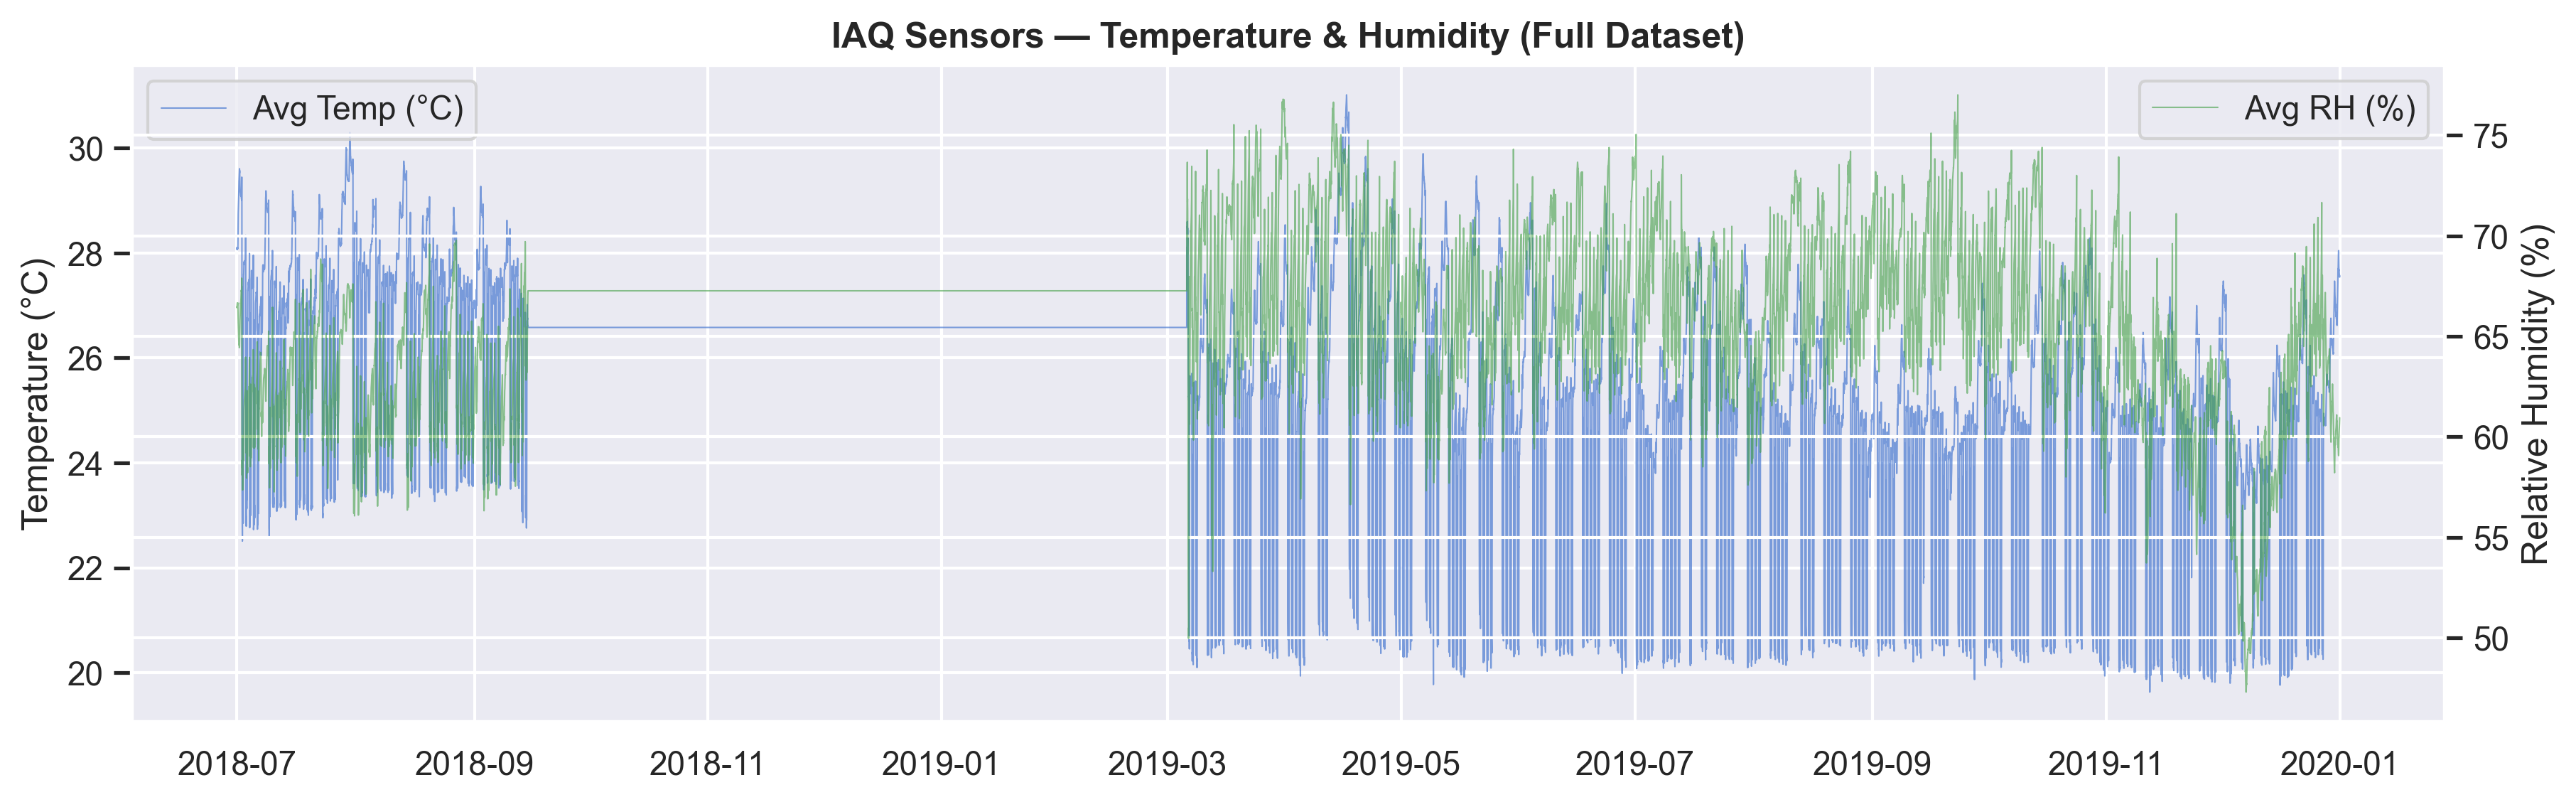

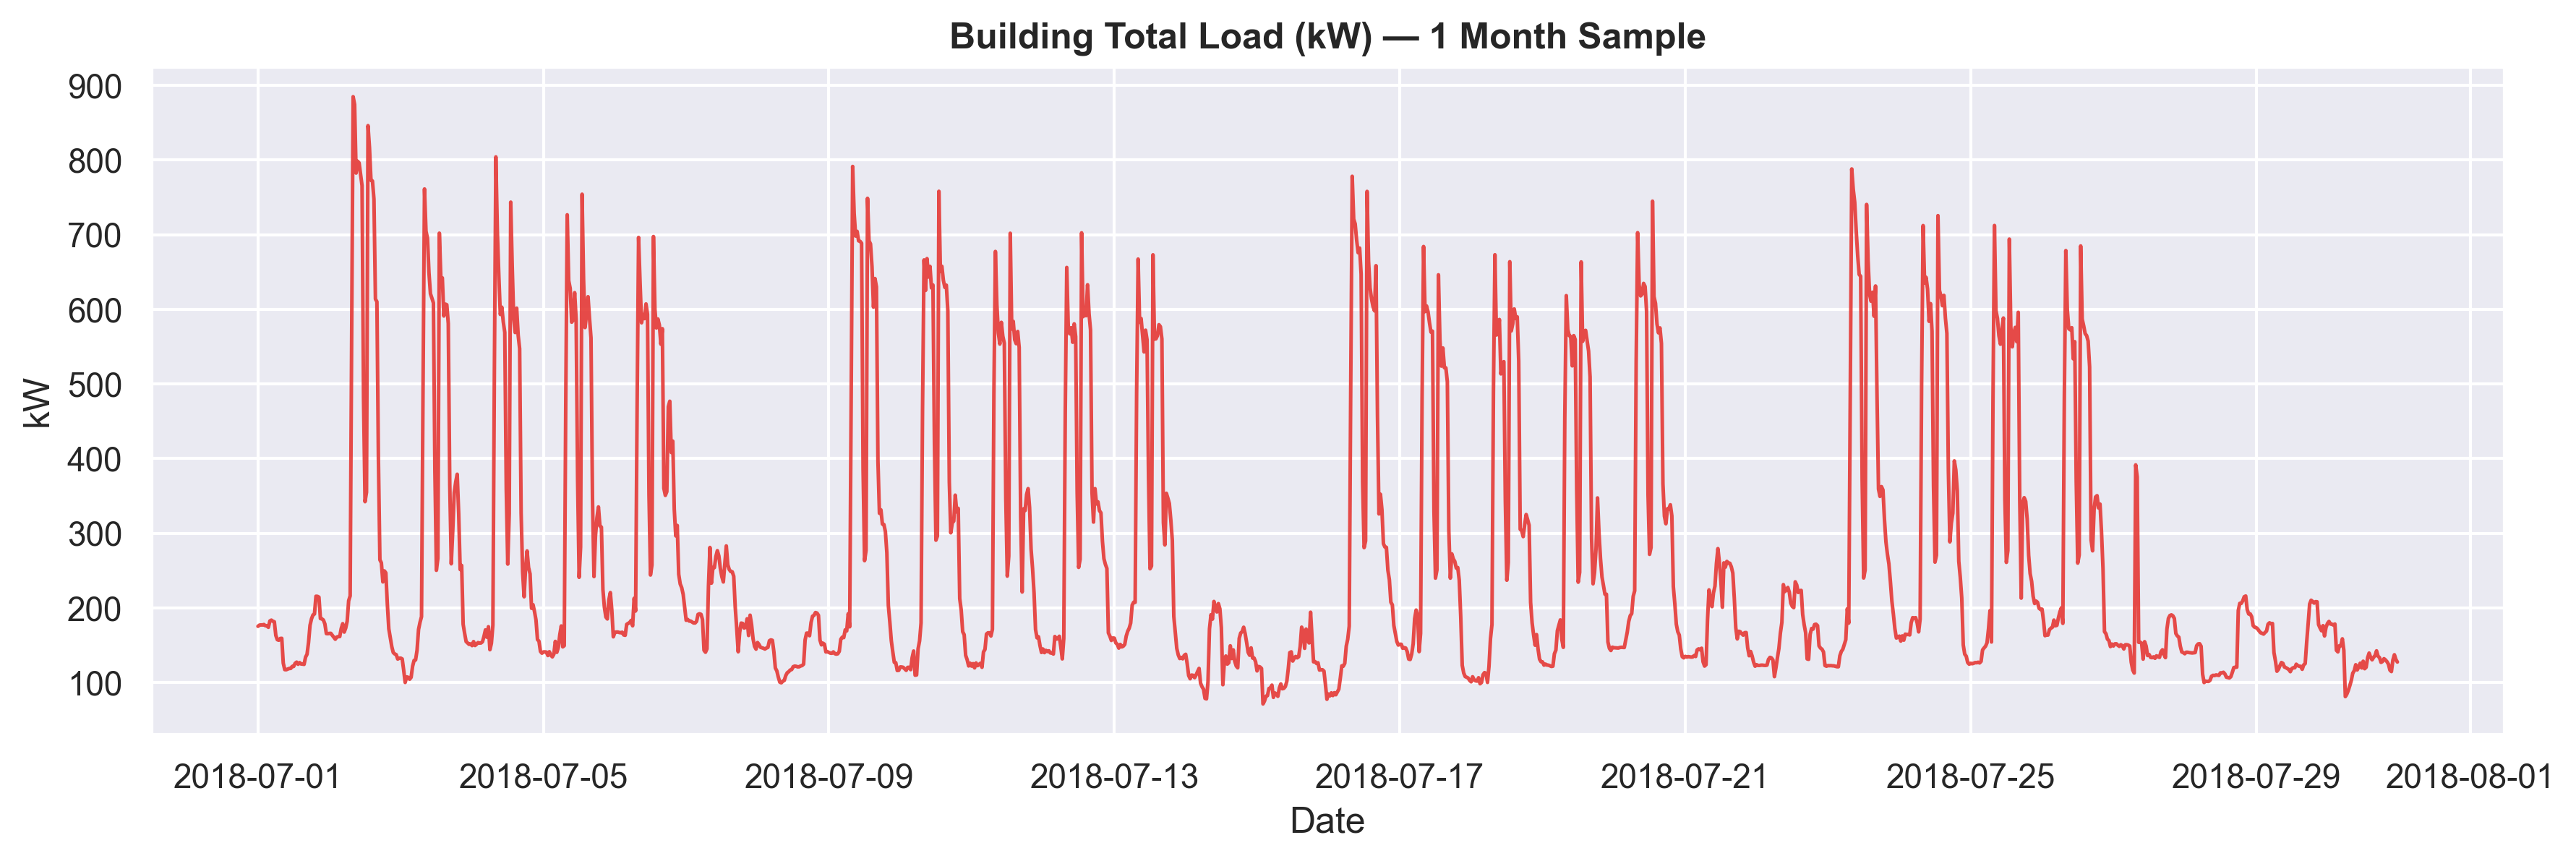

In [30]:
missing = pd.DataFrame({
    'Missing Count': df_30.isnull().sum(),
    'Missing %'    : (df_30.isnull().sum() / len(df_30) * 100).round(3),
    'Dtype'        : df_30.dtypes,
})
print('=== Missing Value Report (after fix) ===')
print(missing.to_string())

fig1, ax2 = plt.subplots(figsize=(14, 4))

# First Plot: IAQ overview
ax2.plot(df_30['avg_temp'], label='Avg Temp (°C)', alpha=0.7, linewidth=0.5)
ax2_r = ax2.twinx()
ax2_r.plot(df_30['avg_rh'],  label='Avg RH (%)', color='#43A047', alpha=0.6, linewidth=0.5)
ax2.set_title('IAQ Sensors — Temperature & Humidity (Full Dataset)', fontweight='bold')
ax2.set_ylabel('Temperature (°C)'); ax2_r.set_ylabel('Relative Humidity (%)')
ax2.legend(loc='upper left'); ax2_r.legend(loc='upper right')

if not RETRAIN_LSTM and not RETRAIN_XGB and os.path.exists("./saved_fig/iaq_overview.png"):
    plt.savefig('./saved_fig/iaq_overview.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

# Second Plot: Total_kW time series (1 month sample)
fig2, ax0 = plt.subplots(figsize=(14, 4))
month_data = df_30['Total_kW'].iloc[:48*30]  # First 30 days (48 intervals/day)
ax0.plot(month_data, color='#E53935', linewidth=1.2, alpha=0.9)
ax0.set_title('Building Total Load (kW) — 1 Month Sample', fontweight='bold')
ax0.set_ylabel('kW'); ax0.set_xlabel('Date')

if not RETRAIN_LSTM and not RETRAIN_XGB and os.path.exists("../saved_fig/building_load_1month.png"):
    plt.savefig('../saved_fig/building_load_1month.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()


## 4. Feature Engineering

Feature matrix shape : (26016, 25)
Number of features   : 24
Features             : ['is_iaq_imputed', 'kw_lag_1', 'kw_lag_2', 'kw_lag_48', 'kw_lag_336', 'kw_roll_mean_4', 'kw_roll_std_4', 'kw_roll_mean_8', 'kw_roll_std_8', 'kw_roll_mean_48', 'kw_roll_std_48', 'avg_temp_lag1', 'avg_temp_roll4', 'avg_rh_lag1', 'avg_rh_roll4', 'avg_lux_lag1', 'avg_lux_roll4', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend']
  → Removed: avg_temp, avg_rh, avg_lux (raw; redundant with their lag1)
  → Added  : is_iaq_imputed (quality flag for ffill-filled sensor rows)


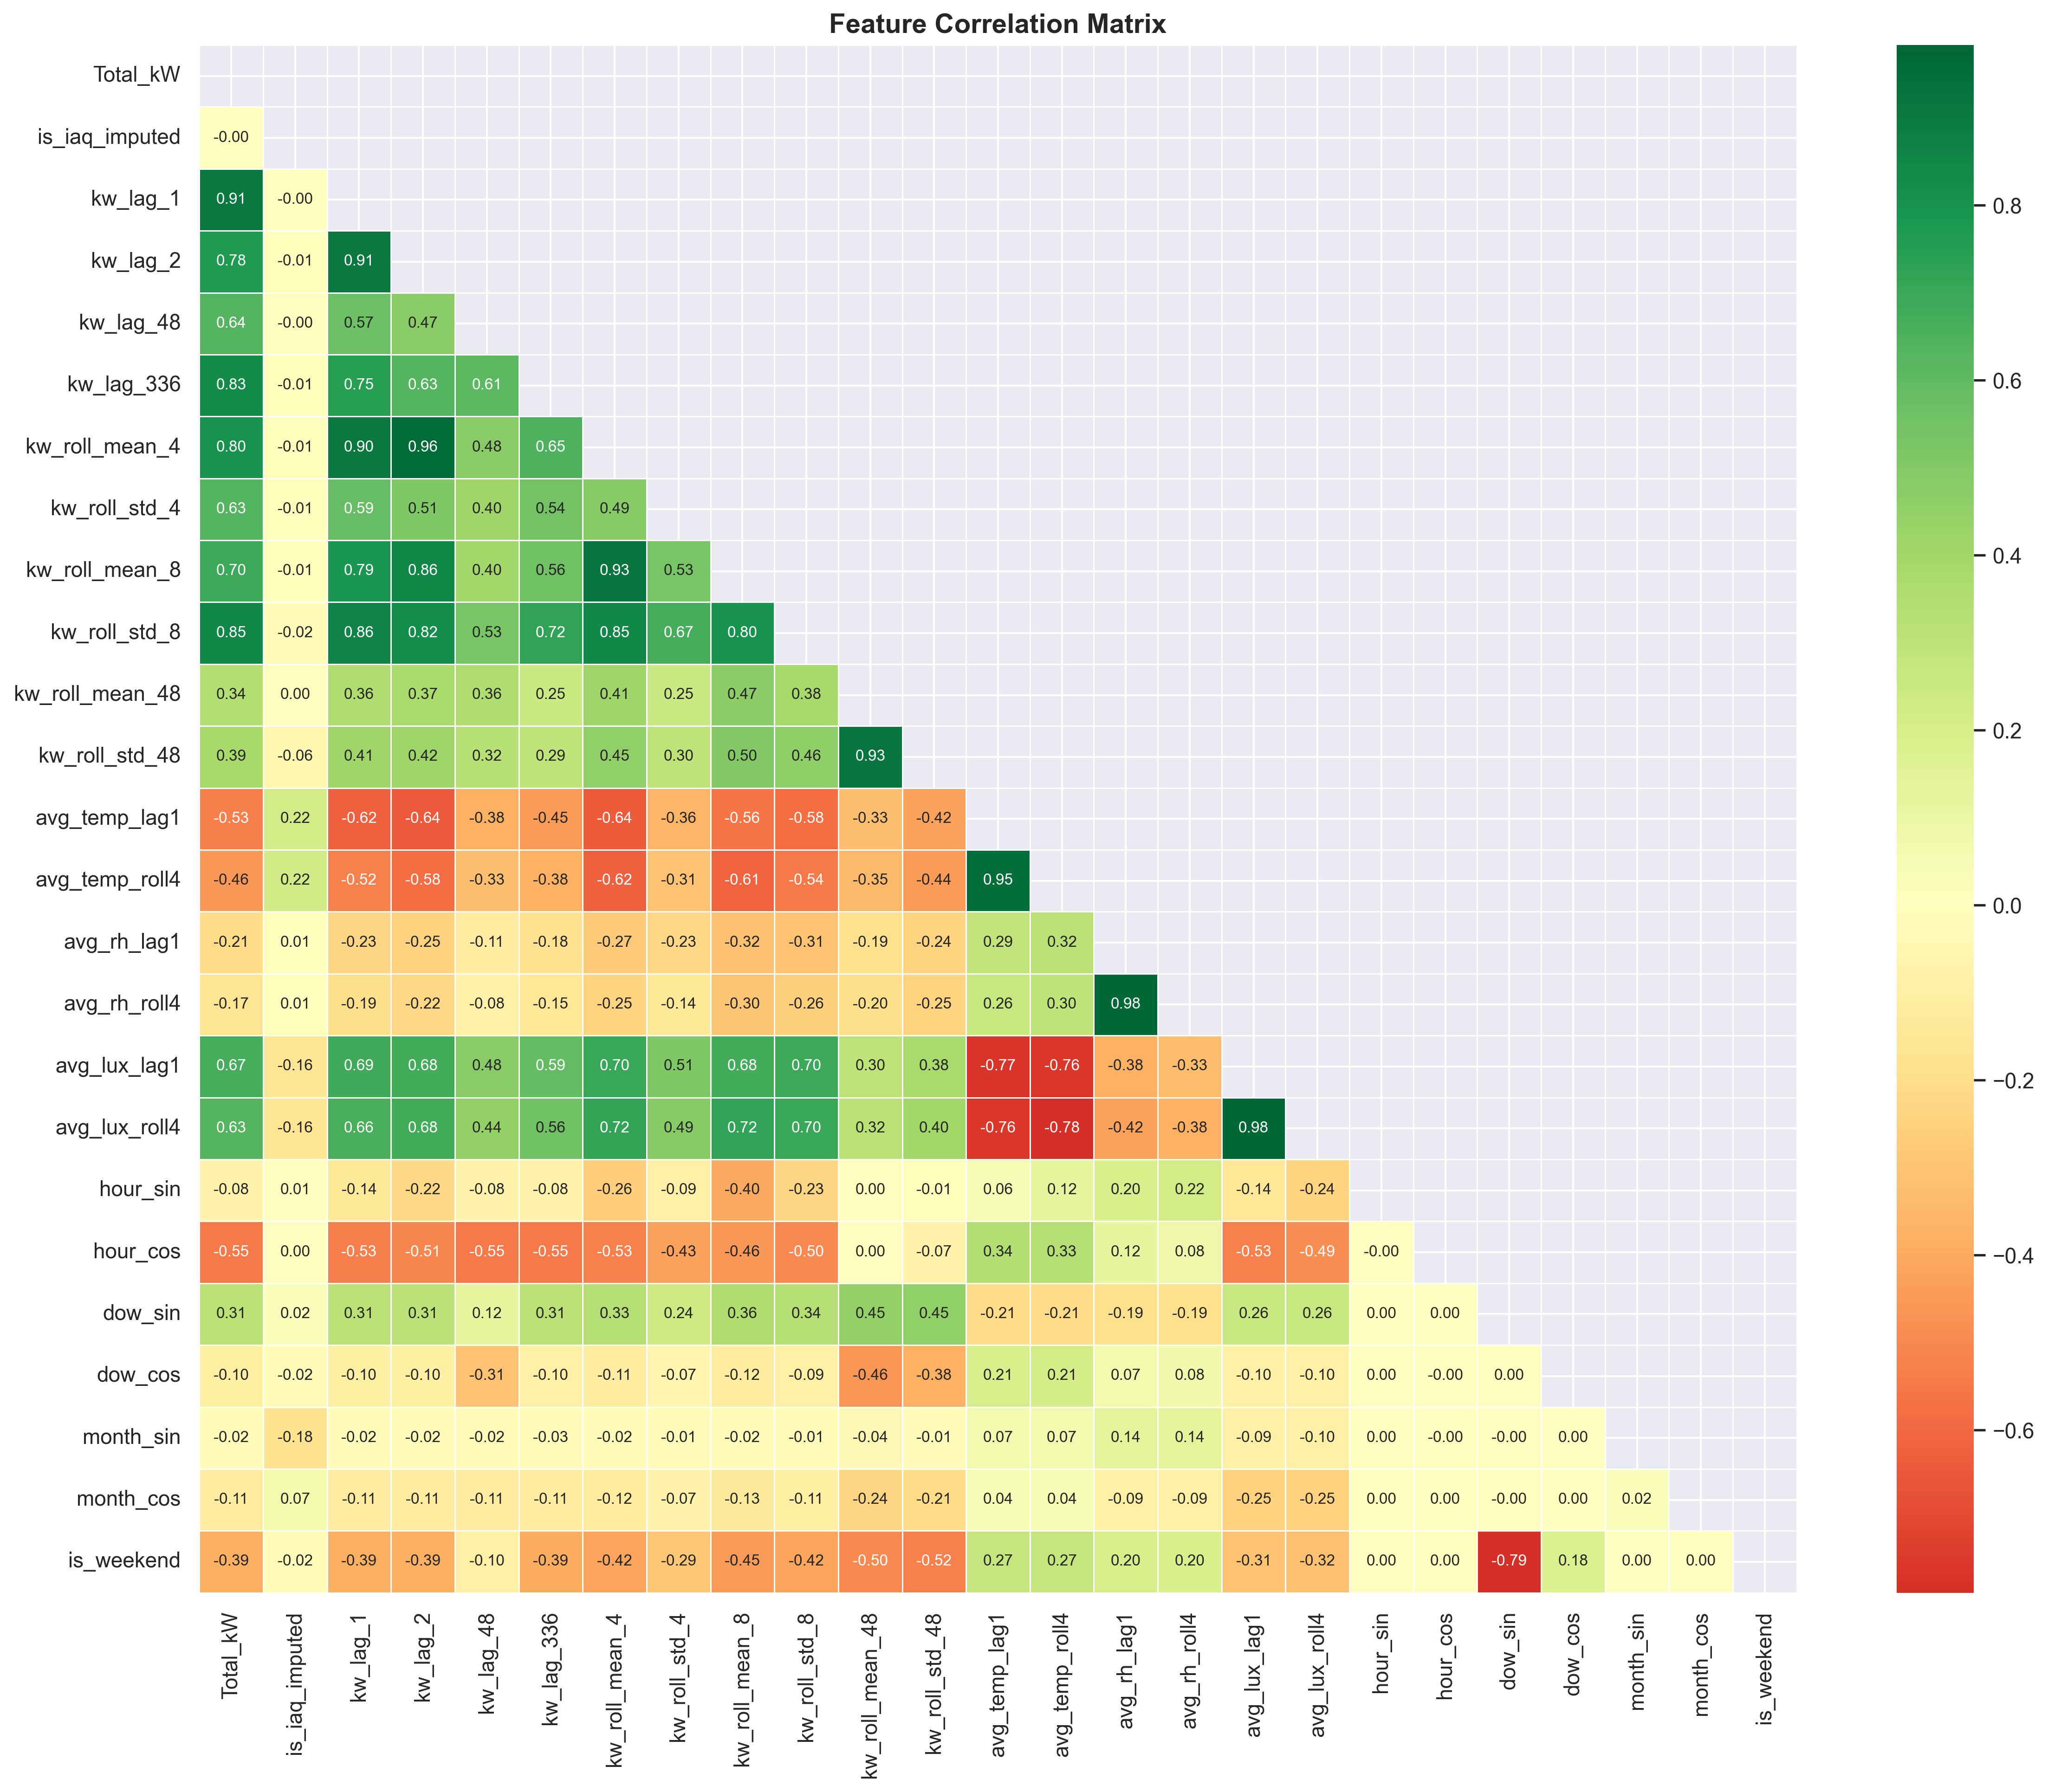

In [31]:
def engineer_features(df):
    """
    Build the features.
    kW temporal    : lag [30 min, 1 hr, 1 day, 1 week],
                     rolling mean & std [2 hr, 4 hr, 24 hr]
    IAQ temporal   : 1-step lag + 2-hr rolling mean for temp, RH%, lux
                     (raw avg_temp/rh/lux columns dropped — redundant with lag1)
    IAQ quality    : is_iaq_imputed binary flag (1 = ffill-filled row)
    Cyclic time    : sin/cos encoding for hour-of-day, day-of-week, month
    Calendar       : is_weekend binary flag
    """
    d = df.copy()

    # kW lag features
    for lag in LAGS:
        d[f'kw_lag_{lag}'] = d[TARGET].shift(lag)

    # kW rolling stats (shift(1) to avoid target leakage)
    for w in ROLL_WINDOWS:
        d[f'kw_roll_mean_{w}'] = d[TARGET].shift(1).rolling(w).mean()
        d[f'kw_roll_std_{w}' ] = d[TARGET].shift(1).rolling(w).std()

    # IAQ lag + rolling only — shift(1) reflects "last known reading"
    # Raw avg_temp/rh/lux are dropped below to remove the redundancy with lag1.
    for col in ['avg_temp', 'avg_rh', 'avg_lux']:
        d[f'{col}_lag1'] = d[col].shift(1)
        d[f'{col}_roll4'] = d[col].shift(1).rolling(4).mean()

    # Drop raw IAQ columns — avg_temp at position k == avg_temp_lag1 at position k+1
    # within every sequence window; keeping both is pure redundancy.
    d.drop(columns=['avg_temp', 'avg_rh', 'avg_lux'], inplace=True)

    # Cyclic time encoding
    d['hour_sin' ] = np.sin(2 * np.pi * d.index.hour        / 24)
    d['hour_cos' ] = np.cos(2 * np.pi * d.index.hour        / 24)
    d['dow_sin'  ] = np.sin(2 * np.pi * d.index.dayofweek   / 7 )
    d['dow_cos'  ] = np.cos(2 * np.pi * d.index.dayofweek   / 7 )
    d['month_sin'] = np.sin(2 * np.pi * d.index.month       / 12)
    d['month_cos'] = np.cos(2 * np.pi * d.index.month       / 12)
    d['is_weekend'] = (d.index.dayofweek >= 5).astype(int)

    d.dropna(inplace=True)
    return d


df_fe = engineer_features(df_30)

FEATURE_COLS = [c for c in df_fe.columns if c != TARGET]
target_idx   = df_fe.columns.get_loc(TARGET)

print(f'Feature matrix shape : {df_fe.shape}')
print(f'Number of features   : {len(FEATURE_COLS)}')
print(f'Features             : {FEATURE_COLS}')
print(f'  → Removed: avg_temp, avg_rh, avg_lux (raw; redundant with their lag1)')
print(f'  → Added  : is_iaq_imputed (quality flag for ffill-filled sensor rows)')

# Correlation heatmap
corr = df_fe.corr()
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.3, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()

if not RETRAIN_LSTM and not RETRAIN_XGB and os.path.exists("../saved_fig/Correlation_heatmap.png"):
    plt.savefig('../saved_fig/Correlation_heatmap.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()


## 5. Utilities

In [32]:
def compute_metrics(y_true, y_pred, label=''):
    
    # Compute RMSE, MAE, R², SMAPE, and NRMSE.
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    r2    = r2_score(y_true, y_pred)
    smape = 200 * np.mean(
        np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )
    nrmse = rmse / (y_true.max() - y_true.min())   # ← ADDED: Methodology §D
    if label:
        print(f'  {label:20s} | RMSE={rmse:8.3f}  MAE={mae:8.3f}  R²={r2:.4f}  SMAPE={smape:.2f}%  NRMSE={nrmse:.4f}')
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'SMAPE': smape, 'NRMSE': nrmse}

def create_sequences(data, target_col_idx, seq_len):
   
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len, target_col_idx])
    return np.array(X), np.array(y)


def build_lstm(input_shape):
    
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        BatchNormalization(), Dropout(0.2),

        LSTM(64, return_sequences=True),
        BatchNormalization(), Dropout(0.2),

        LSTM(32, return_sequences=False),
        BatchNormalization(), Dropout(0.2),

        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse', metrics=['mae']
    )
    return model


def build_xgboost():
    return XGBRegressor(
        n_estimators          = XGB_N_EST,
        learning_rate         = XGB_LR,
        max_depth             = XGB_DEPTH,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        random_state          = SEED,
        early_stopping_rounds = XGB_EARLY_STOP,
        verbosity             = 0,
    )


print('Utility functions defined ✓')
print('  Metrics: RMSE, MAE, R², SMAPE, NRMSE')
print('  SMAPE: symmetric, bounded [0,200%], safe for near-zero values')
print('  NRMSE: scale-normalised — Methodology Section D')


Utility functions defined ✓
  Metrics: RMSE, MAE, R², SMAPE, NRMSE
  SMAPE: symmetric, bounded [0,200%], safe for near-zero values
  NRMSE: scale-normalised — Methodology Section D


## 6. TimeSeriesSplit Cross-Validation

In [33]:
if not RETRAIN_LSTM and not RETRAIN_XGB and os.path.exists("../saved_cv/lstm_cv_metrics.csv") and os.path.exists("../saved_cv/xgb_cv_metrics.csv"):
    lstm_cv_df = pd.read_csv ("../saved_cv/lstm_cv_metrics.csv") #used when loading models only
    xgb_cv_df  = pd.read_csv ("../saved_cv/xgb_cv_metrics.csv")  #used when loading models only    

    print('\n' + '='*65)
    print(f'  {"Metric":<8}  {"LSTM (mean ± std)":>22}  {"XGBoost (mean ± std)":>24}')
    print('='*65)
    for metric in ['RMSE', 'MAE', 'R2', 'SMAPE', 'NRMSE']:
        lv = f'{lstm_cv_df[metric].mean():.4f} ± {lstm_cv_df[metric].std():.4f}'
        xv = f'{xgb_cv_df[metric].mean():.4f} ± {xgb_cv_df[metric].std():.4f}'
        print(f'  {metric:<8}  {lv:>22}  {xv:>24}')
    print('='*65)

else:
    data_array = df_fe.values
    tscv = TimeSeriesSplit(n_splits=N_FOLDS)

    lstm_cv, xgb_cv = [], []

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(data_array)):
        print(f'\n── Fold {fold+1}/{N_FOLDS}  '
            f'(train={len(tr_idx):,}  val={len(val_idx):,}) ──')

        tr_data  = data_array[tr_idx]
        val_data = data_array[val_idx]

        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()
        tr_sc    = scaler_X.fit_transform(tr_data)
        val_sc   = scaler_X.transform(val_data)
        scaler_y.fit(tr_data[:, target_idx].reshape(-1, 1))

        X_tr,  y_tr  = create_sequences(tr_sc,  target_idx, SEQ_LENGTH)
        X_val, y_val = create_sequences(val_sc, target_idx, SEQ_LENGTH)

        if len(X_tr) < 200 or len(X_val) < 50:
            print('  Skipped — not enough samples for this fold.')
            continue

        y_true = scaler_y.inverse_transform(y_val.reshape(-1, 1)).flatten()

        # ── LSTM ──────────────────────────────────────────────────────
        lstm = build_lstm((SEQ_LENGTH, X_tr.shape[2]))
        es   = EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True, verbose=0)
        rlr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=5, min_lr=1e-5, verbose=0)
        lstm.fit(X_tr, y_tr, epochs=50, batch_size=LSTM_BATCH,
                validation_data=(X_val, y_val), callbacks=[es, rlr], verbose=0)

        y_pred_l = scaler_y.inverse_transform(
            lstm.predict(X_val, verbose=0)).flatten()
        m_l = compute_metrics(y_true, y_pred_l, label='LSTM')
        m_l['fold'] = fold + 1
        lstm_cv.append(m_l)

        # ── XGBoost ───────────────────────────────────────────────────
        X_tr_f   = X_tr.reshape(len(X_tr),   -1)
        X_val_f  = X_val.reshape(len(X_val), -1)
        xgb = build_xgboost()
        xgb.fit(X_tr_f, y_tr, eval_set=[(X_val_f, y_val)], verbose=False)

        y_pred_x = scaler_y.inverse_transform(
            xgb.predict(X_val_f).reshape(-1, 1)).flatten()
        m_x = compute_metrics(y_true, y_pred_x, label='XGBoost')
        m_x['fold'] = fold + 1
        xgb_cv.append(m_x)

    # ── CV Summary ────────────────────────────────────────────────────
    lstm_cv_df = pd.DataFrame(lstm_cv)
    xgb_cv_df  = pd.DataFrame(xgb_cv)

    print('\n' + '='*65)
    print(f'  {"Metric":<8}  {"LSTM (mean ± std)":>22}  {"XGBoost (mean ± std)":>24}')
    print('='*65)
    for metric in ['RMSE', 'MAE', 'R2', 'SMAPE', 'NRMSE']:
        lv = f'{lstm_cv_df[metric].mean():.4f} ± {lstm_cv_df[metric].std():.4f}'
        xv = f'{xgb_cv_df[metric].mean():.4f} ± {xgb_cv_df[metric].std():.4f}'
        print(f'  {metric:<8}  {lv:>22}  {xv:>24}')
    print('='*65)

    # Add this to the end of Section 6 to save the metrics
    lstm_cv_df.to_csv('../saved_cv/lstm_cv_metrics.csv', index=False)
    xgb_cv_df.to_csv('../saved_cv/xgb_cv_metrics.csv', index=False)


  Metric         LSTM (mean ± std)      XGBoost (mean ± std)
  RMSE           48.1040 ± 30.8295          27.6479 ± 6.7840
  MAE            32.4744 ± 21.1455          16.3082 ± 3.5865
  R2               0.9002 ± 0.1260           0.9754 ± 0.0112
  SMAPE           14.5085 ± 7.6215           7.4955 ± 1.0452
  NRMSE            0.0614 ± 0.0420           0.0346 ± 0.0079


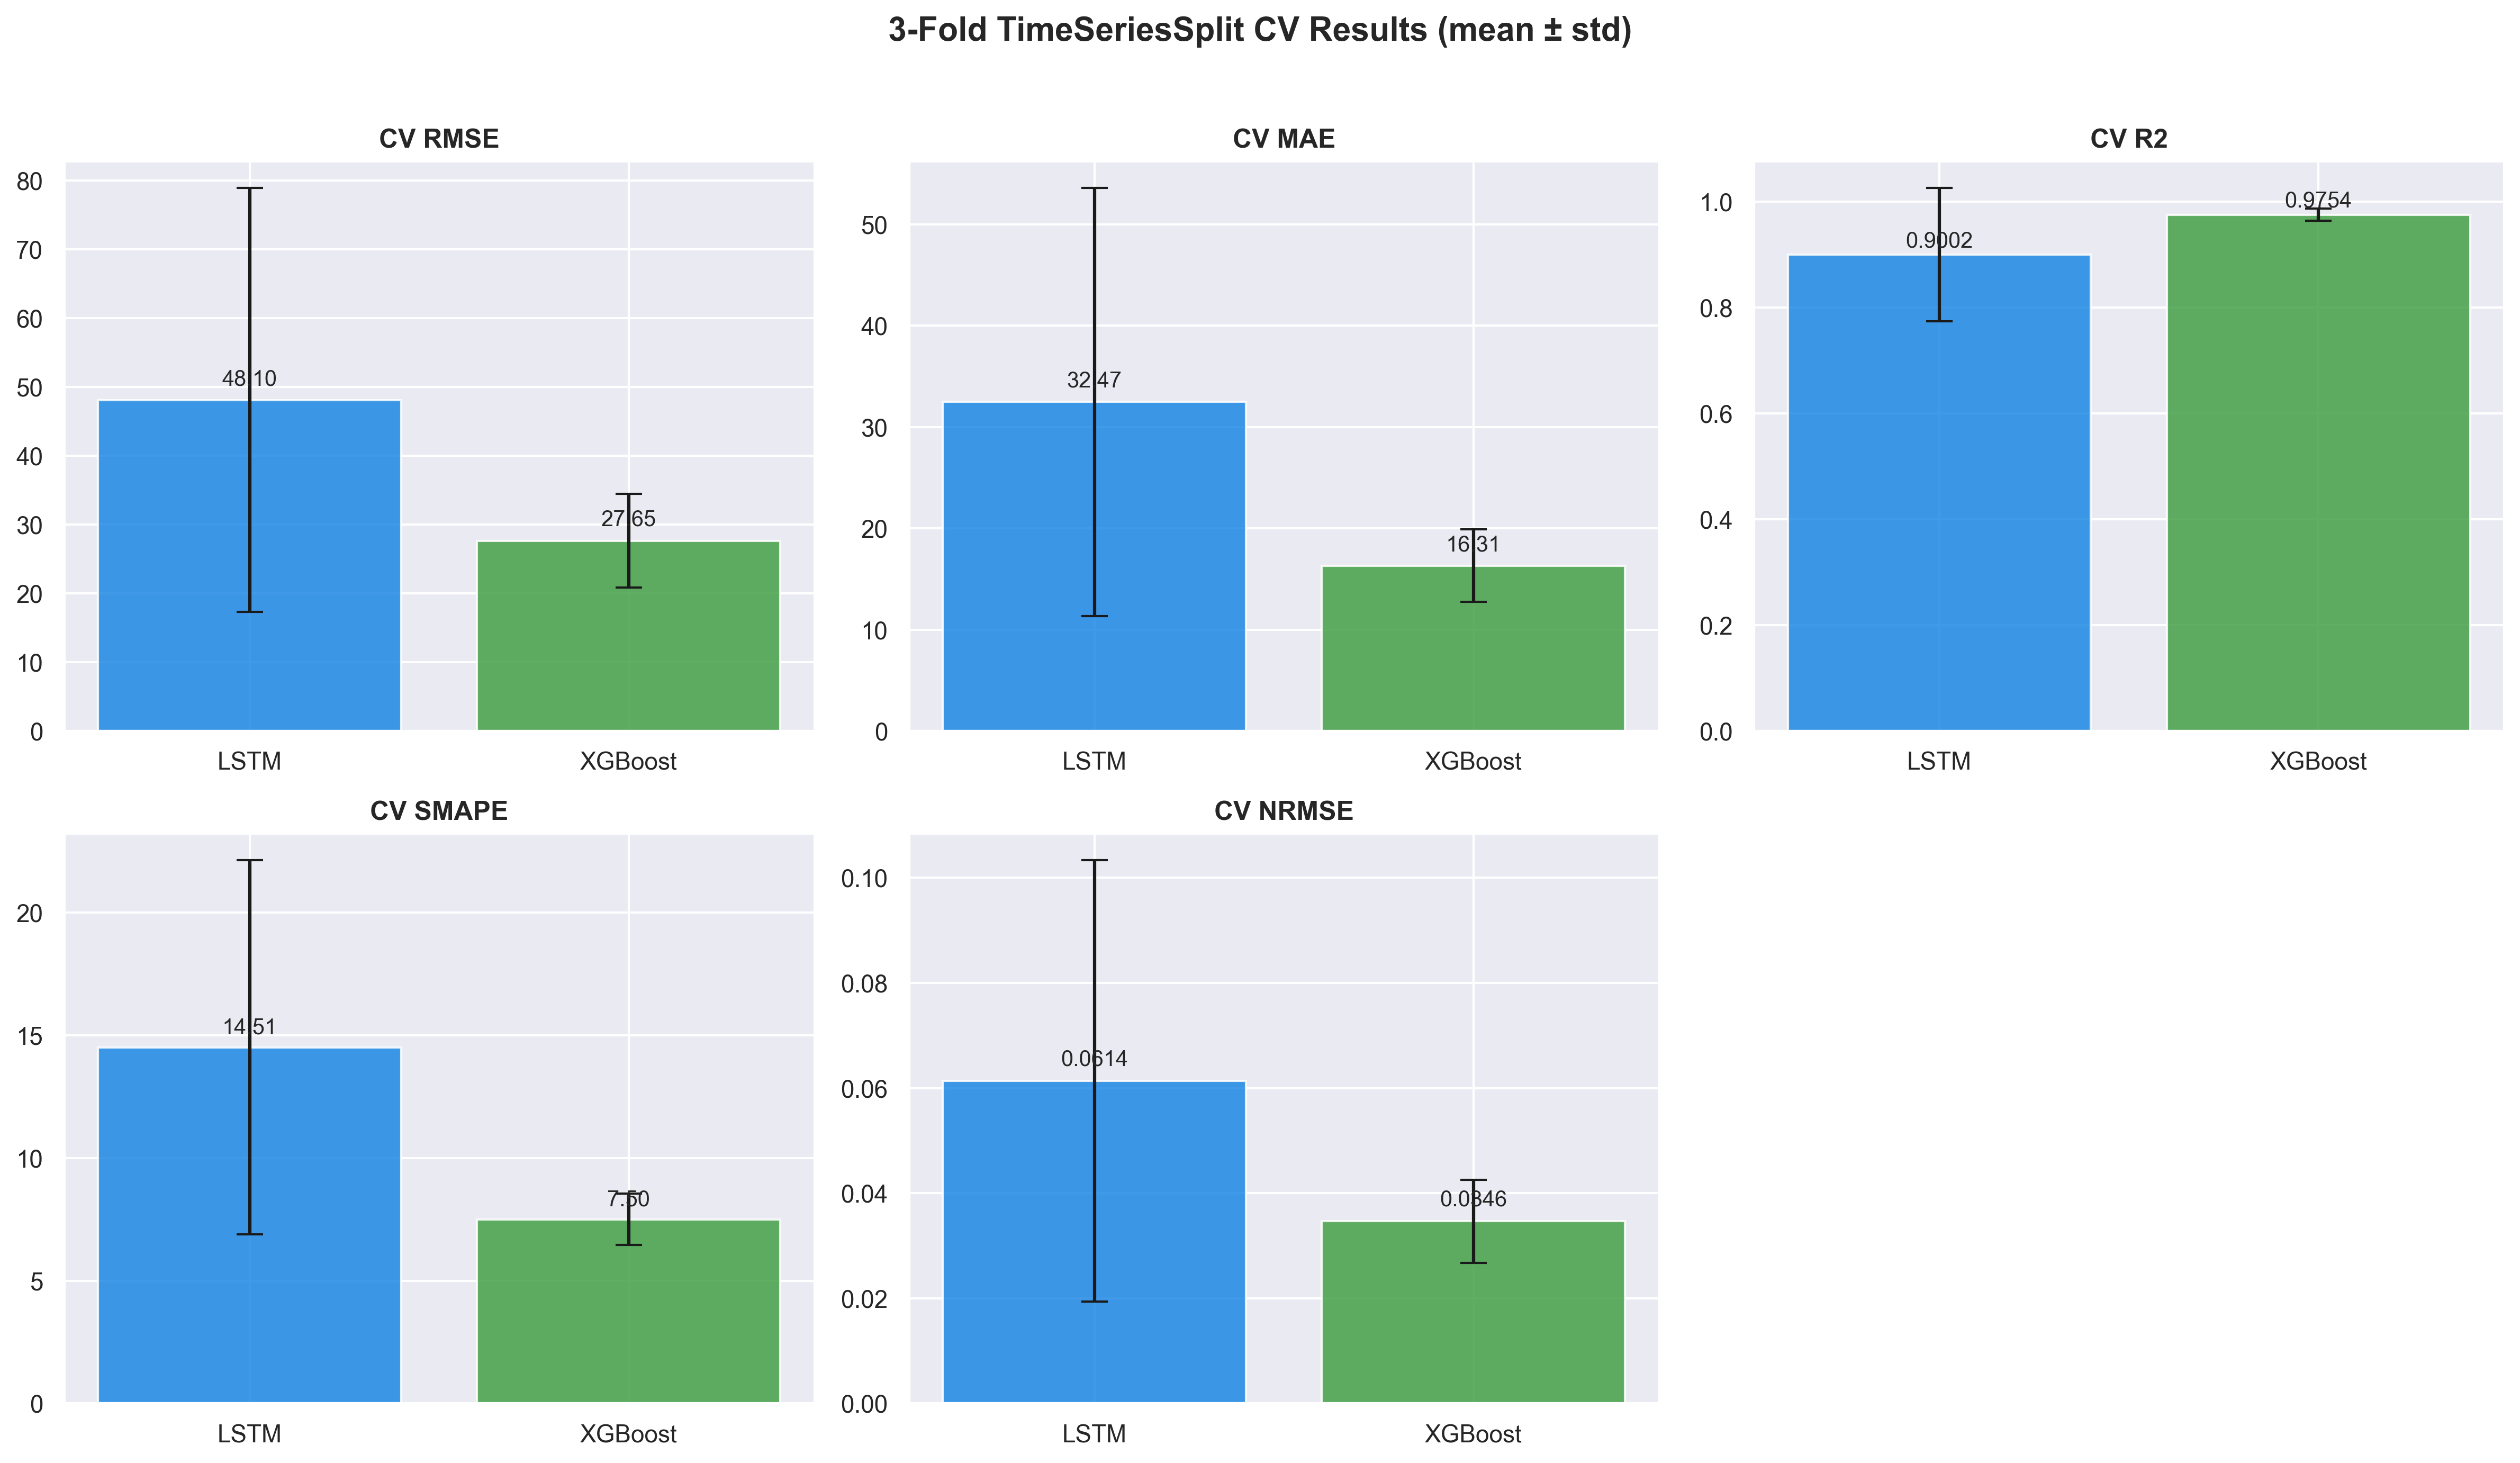

In [34]:
# CV metrics bar chart (mean ± std error bars)
if lstm_cv_df.shape[0] > 0 and xgb_cv_df.shape[0] > 0:
    metrics_to_plot = ['RMSE', 'MAE', 'R2', 'SMAPE', 'NRMSE']
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes_flat = axes.flatten()

    for i, metric in enumerate(metrics_to_plot):
        ax = axes_flat[i]
        means = [lstm_cv_df[metric].mean(), xgb_cv_df[metric].mean()]
        stds  = [lstm_cv_df[metric].std(),  xgb_cv_df[metric].std() ]
        bars  = ax.bar(['LSTM', 'XGBoost'], means, yerr=stds,
                       color=['#1E88E5', '#43A047'], capsize=6,
                       edgecolor='white', linewidth=1, alpha=0.85)
        ax.set_title(f'CV {metric}', fontweight='bold')
        for bar, m in zip(bars, means):
            fmt = f'{m:.4f}' if metric in ['R2', 'NRMSE'] else f'{m:.2f}'
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(stds)*0.05,
                    fmt, ha='center', va='bottom', fontsize=10, fontweight='500')

    # Hide the 6th subplot (bottom right)
    axes_flat[5].set_visible(False)

    plt.suptitle('3-Fold TimeSeriesSplit CV Results (mean ± std)',
                 fontweight='bold', fontsize=15, y=1.02)
    plt.tight_layout()

    if not RETRAIN_LSTM and not RETRAIN_XGB and os.path.exists("../saved_fig/cv_metrics_barchart.png"):
        plt.savefig('../saved_fig/cv_metrics_barchart.png', dpi=150, bbox_inches='tight')
    plt.show()



## Train Model


## 7. Final Model Training (70 / 15 / 15 Split)

In [35]:
n        = len(data_array)
tr_end   = int(n * SPLIT_TRAIN)
val_end  = int(n * SPLIT_VAL)

tr_data  = data_array[:tr_end]
val_data = data_array[tr_end:val_end]
te_data  = data_array[val_end:]

if not RETRAIN_LSTM and not RETRAIN_XGB:
    data_array = df_fe.values

else:    
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    tr_sc  = scaler_X.fit_transform(tr_data)
    val_sc = scaler_X.transform(val_data)
    te_sc  = scaler_X.transform(te_data)
    scaler_y.fit(tr_data[:, target_idx].reshape(-1, 1))

    X_tr,  y_tr  = create_sequences(tr_sc,  target_idx, SEQ_LENGTH)
    X_val, y_val = create_sequences(val_sc, target_idx, SEQ_LENGTH)
    X_te,  y_te  = create_sequences(te_sc,  target_idx, SEQ_LENGTH)

    y_true_test = scaler_y.inverse_transform(y_te.reshape(-1, 1)).flatten()

    print(f'Train sequences : {X_tr.shape}')
    print(f'Val   sequences : {X_val.shape}')
    print(f'Test  sequences : {X_te.shape}')
    print(f'Features per step: {X_tr.shape[2]}')

    # ── Save scalers (always — needed for model loading later) ────────────
    os.makedirs(MODEL_DIR, exist_ok=True)
    joblib.dump(scaler_X, SCALER_X_PATH)
    joblib.dump(scaler_y, SCALER_Y_PATH)
    print(f'Scalers saved → {MODEL_DIR}/')


In [36]:
if not RETRAIN_LSTM and os.path.exists(LSTM_MODEL_PATH):
    print(f'Loading saved LSTM from {LSTM_MODEL_PATH} ...')
    lstm_final   = tf.keras.models.load_model(LSTM_MODEL_PATH)
    scaler_X     = joblib.load(SCALER_X_PATH)
    scaler_y     = joblib.load(SCALER_Y_PATH)
    # Rebuild sequences with loaded scalers so downstream cells work
    tr_sc  = scaler_X.transform(tr_data)
    val_sc = scaler_X.transform(val_data)
    te_sc  = scaler_X.transform(te_data)
    X_tr,  y_tr  = create_sequences(tr_sc,  target_idx, SEQ_LENGTH)
    X_val, y_val = create_sequences(val_sc, target_idx, SEQ_LENGTH)
    X_te,  y_te  = create_sequences(te_sc,  target_idx, SEQ_LENGTH)
    y_true_test  = scaler_y.inverse_transform(y_te.reshape(-1,1)).flatten()
    history_lstm = None   # no history when loading
    print('LSTM loaded ✓  (skipped training)')
else:
    print('No saved LSTM found — training from scratch.')
    print('Training final LSTM...')
    lstm_final = build_lstm((SEQ_LENGTH, X_tr.shape[2]))
    lstm_final.summary()

    es  = EarlyStopping(monitor='val_loss', patience=LSTM_PATIENCE,
                        restore_best_weights=True)
    rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                             patience=5, min_lr=1e-5)

    history_lstm = lstm_final.fit(
        X_tr, y_tr,
        epochs          = LSTM_EPOCHS,
        batch_size      = LSTM_BATCH,
        validation_data = (X_val, y_val),
        callbacks       = [es, rlr],
        verbose         = 1,
    )

    # Save model after training
    lstm_final.save(LSTM_MODEL_PATH)
    print(f'\nLSTM saved → {LSTM_MODEL_PATH}')

y_pred_lstm = scaler_y.inverse_transform(
    lstm_final.predict(X_te, verbose=0)).flatten()

print('\n--- LSTM Test Performance ---')
lstm_test_metrics = compute_metrics(y_true_test, y_pred_lstm, label='LSTM')


Loading saved LSTM from ../saved_models\lstm_final.keras ...
LSTM loaded ✓  (skipped training)

--- LSTM Test Performance ---
  LSTM                 | RMSE=  28.211  MAE=  17.929  R²=0.9681  SMAPE=10.51%  NRMSE=0.0395


In [37]:
X_tr_f  = X_tr.reshape(len(X_tr),   -1)
X_val_f = X_val.reshape(len(X_val), -1)
X_te_f  = X_te.reshape(len(X_te),   -1)

if not RETRAIN_XGB and os.path.exists(XGB_MODEL_PATH):
    print(f'Loading saved XGBoost from {XGB_MODEL_PATH} ...')
    xgb_final = build_xgboost()
    xgb_final.load_model(XGB_MODEL_PATH)
    print('XGBoost loaded ✓  (skipped training)')
else:
    if not RETRAIN_XGB:
        print('No saved XGBoost found — training from scratch.')
    print('Training final XGBoost...')
    xgb_final = build_xgboost()
    xgb_final.set_params(early_stopping_rounds=XGB_EARLY_STOP)
    xgb_final.fit(
        X_tr_f, y_tr,
        eval_set = [(X_val_f, y_val)],
        verbose  = 100,
    )

    # Save model after training
    xgb_final.save_model(XGB_MODEL_PATH)
    print(f'\nXGBoost saved → {XGB_MODEL_PATH}')

y_pred_xgb = scaler_y.inverse_transform(
    xgb_final.predict(X_te_f).reshape(-1, 1)).flatten()

print('\n--- XGBoost Test Performance ---')
xgb_test_metrics = compute_metrics(y_true_test, y_pred_xgb, label='XGBoost')


Loading saved XGBoost from ../saved_models\xgb_final.json ...
XGBoost loaded ✓  (skipped training)

--- XGBoost Test Performance ---
  XGBoost              | RMSE=  21.349  MAE=  12.659  R²=0.9818  SMAPE=6.95%  NRMSE=0.0299


In [38]:
# Naive persistence: predict t+1 = t
naive_pred = y_true_test[:-1]
naive_true = y_true_test[1:]
naive_metrics = compute_metrics(naive_true, naive_pred, label='Naive Persistence')

print('\n--- Naive Persistence Baseline ---')
for k, v in naive_metrics.items():
    print(f'  {k}: {v:.4f}')

# Improvement over naive
for model_name, m in [('LSTM', lstm_test_metrics), ('XGBoost', xgb_test_metrics)]:
    imp_mae  = (naive_metrics['MAE']  - m['MAE'])  / naive_metrics['MAE']  * 100
    imp_rmse = (naive_metrics['RMSE'] - m['RMSE']) / naive_metrics['RMSE'] * 100
    print(f'  {model_name} improvement over naive — MAE: {imp_mae:.1f}%  RMSE: {imp_rmse:.1f}%')

  Naive Persistence    | RMSE=  66.845  MAE=  27.184  R²=0.8211  SMAPE=11.10%  NRMSE=0.0936

--- Naive Persistence Baseline ---
  RMSE: 66.8446
  MAE: 27.1841
  R2: 0.8211
  SMAPE: 11.0988
  NRMSE: 0.0936
  LSTM improvement over naive — MAE: 34.0%  RMSE: 57.8%
  XGBoost improvement over naive — MAE: 53.4%  RMSE: 68.1%


## 8. Evaluation

In [39]:
results_df = pd.DataFrame([
    {'Model': 'LSTM',              **lstm_test_metrics},
    {'Model': 'XGBoost',           **xgb_test_metrics},
    {'Model': 'Naive Persistence', **{k: (naive_metrics.get(k) if k != 'R2' else
                                        r2_score(naive_true, naive_pred))
                                      for k in ['RMSE','MAE','R2','SMAPE','NRMSE']}},
]).set_index('Model')

results_df['RMSE']  = results_df['RMSE'].round(4)
results_df['MAE']   = results_df['MAE'].round(4)
results_df['R2']    = results_df['R2'].round(4)
results_df['SMAPE'] = results_df['SMAPE'].round(2)
results_df['NRMSE'] = results_df['NRMSE'].round(4)

print('='*68)
print('  Final Test Set — Model Comparison Table')
print('='*68)
print(results_df.to_string())
print('='*68)

best = {
    'RMSE' : results_df['RMSE'].idxmin(),
    'MAE'  : results_df['MAE'].idxmin(),
    'R2'   : results_df['R2'].idxmax(),
    'SMAPE': results_df['SMAPE'].idxmin(),
    'NRMSE': results_df['NRMSE'].idxmin(),
}
print('\nBest per metric:')
for metric, model in best.items():
    print(f'  {metric:6s} → {model}')


  Final Test Set — Model Comparison Table
                      RMSE      MAE      R2  SMAPE   NRMSE
Model                                                     
LSTM               28.2108  17.9291  0.9681  10.51  0.0395
XGBoost            21.3486  12.6593  0.9818   6.95  0.0299
Naive Persistence  66.8446  27.1841  0.8211  11.10  0.0936

Best per metric:
  RMSE   → XGBoost
  MAE    → XGBoost
  R2     → XGBoost
  SMAPE  → XGBoost
  NRMSE  → XGBoost


## 9. Visualizations

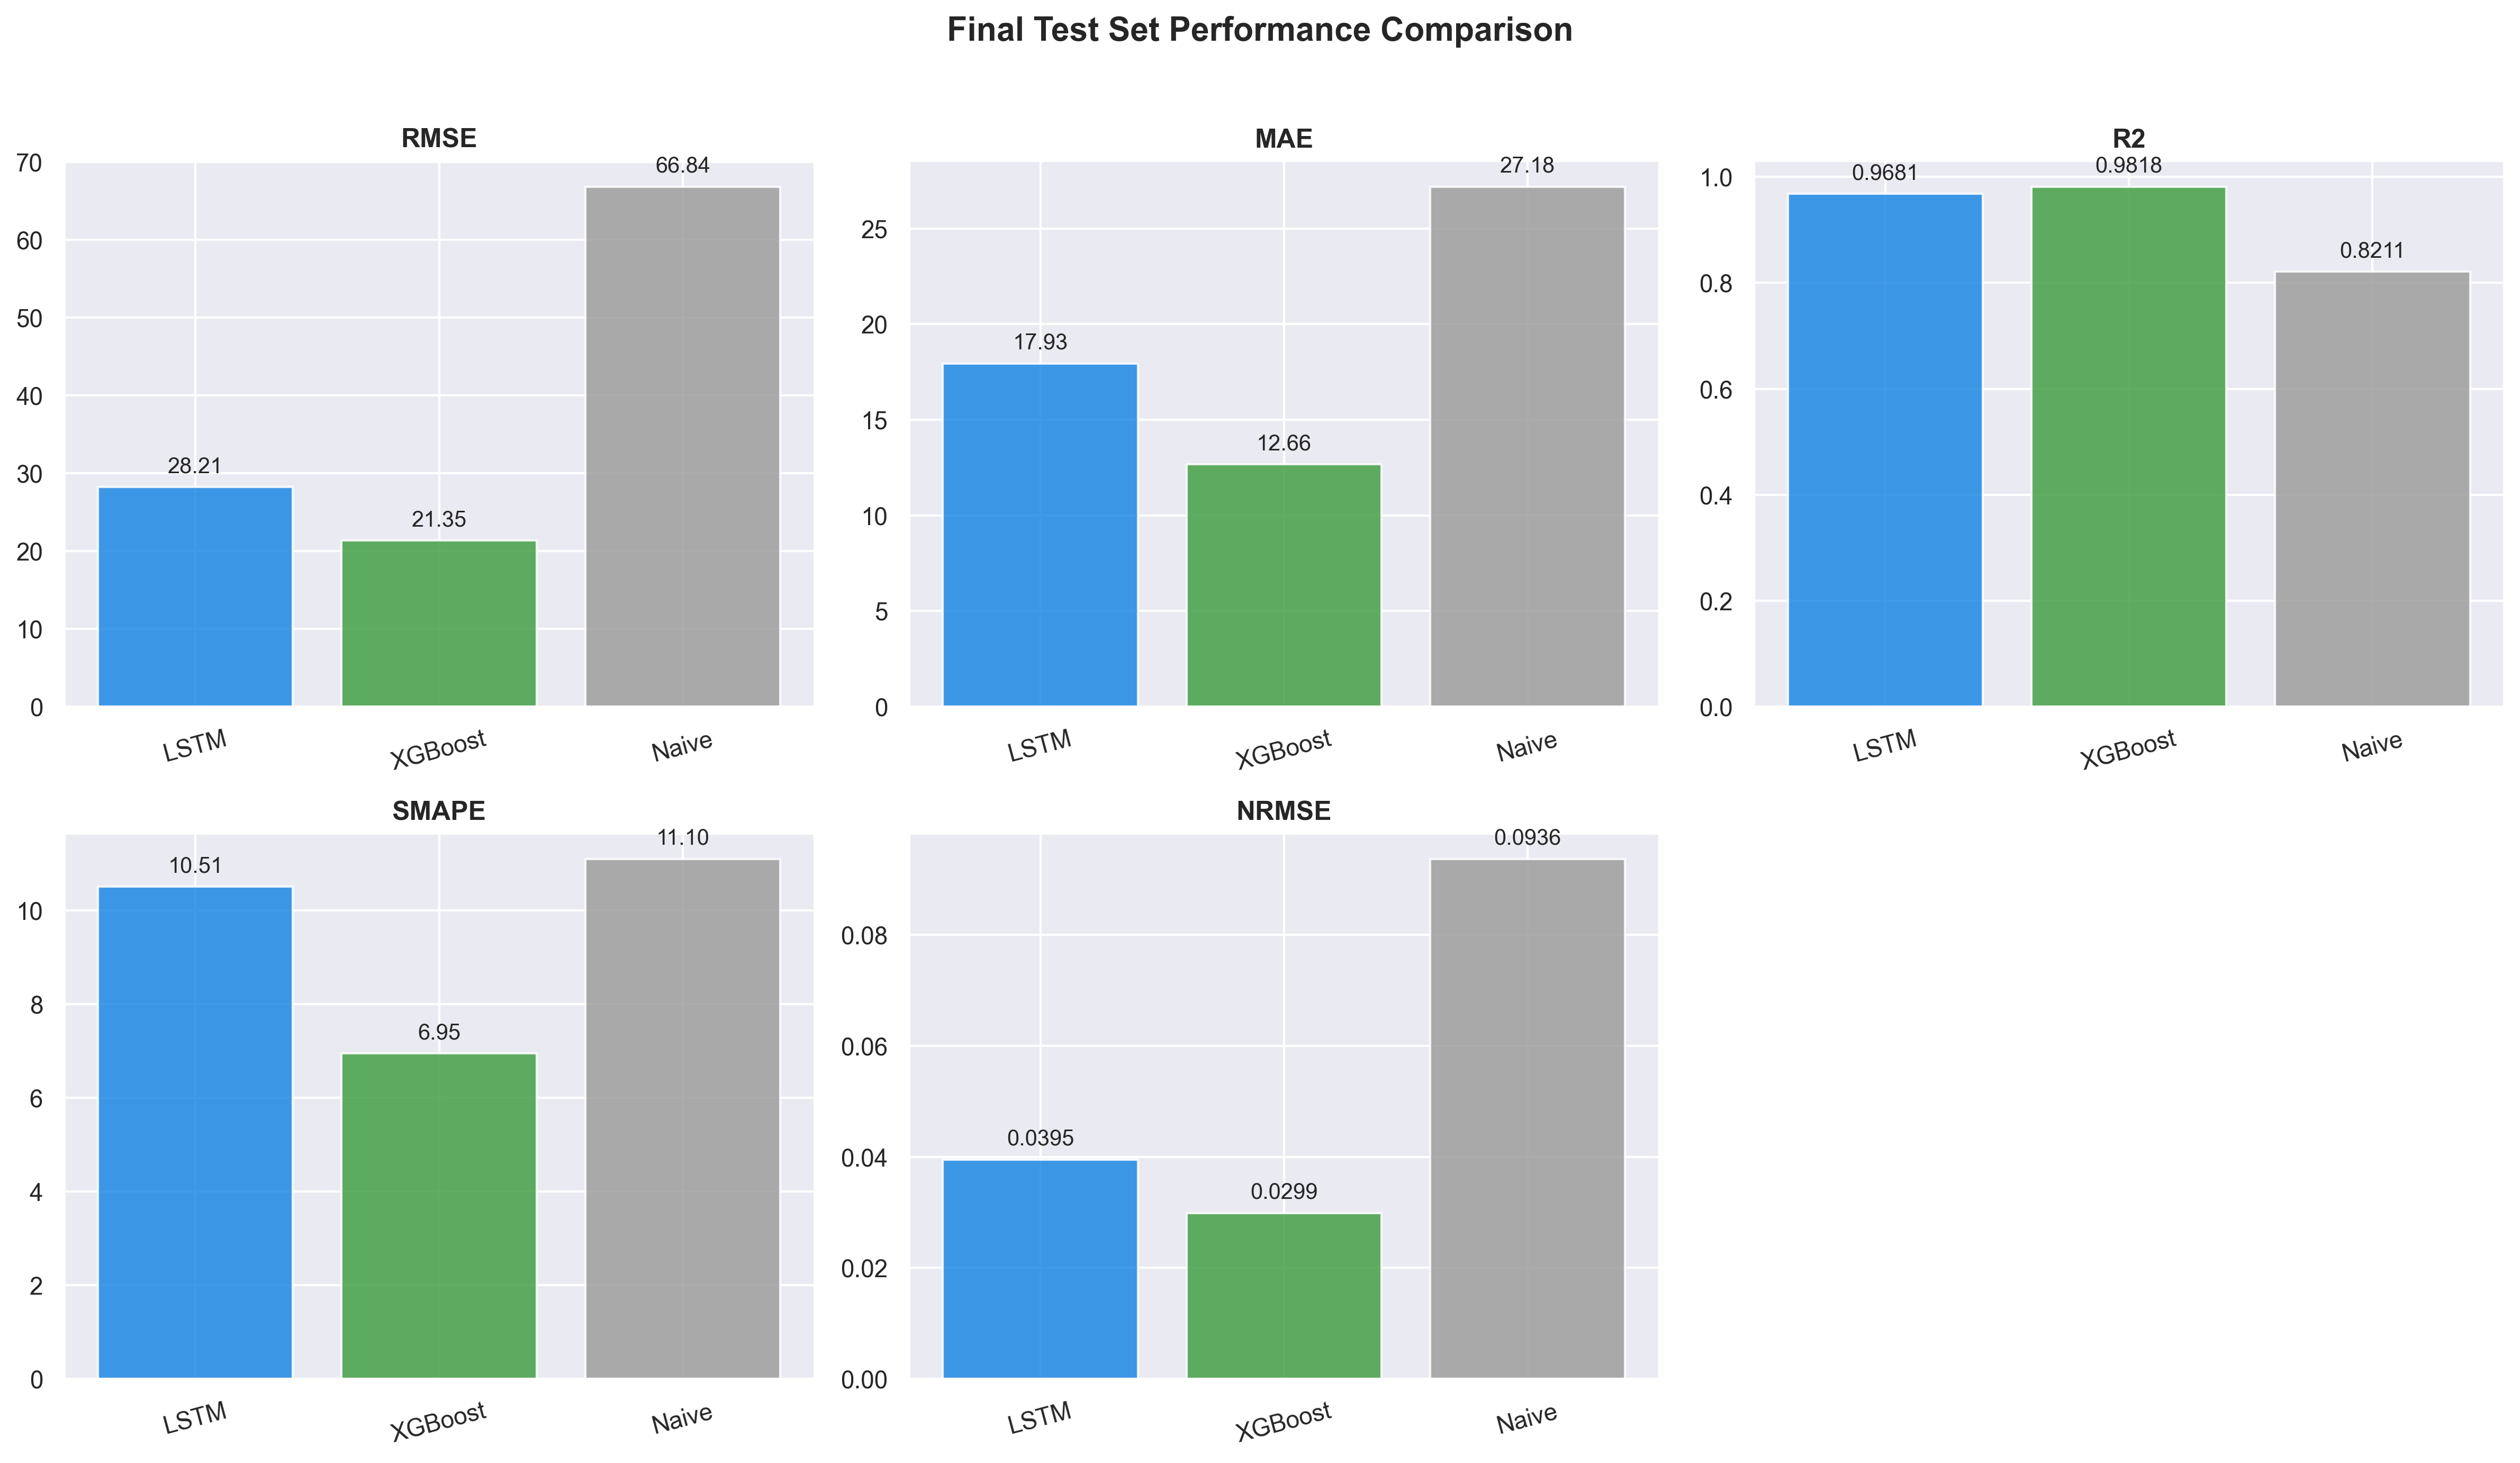

In [40]:
# ── Final Test Set Metrics Bar Chart ───────────────────────────────
metrics_to_plot = ['RMSE', 'MAE', 'R2', 'SMAPE', 'NRMSE']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

# We use the results_df generated in Section 8
models = results_df.index.tolist() # ['LSTM', 'XGBoost', 'Naive Persistence']
colors = ['#1E88E5', '#43A047', '#9E9E9E'] # Blue, Green, Grey

for i, metric in enumerate(metrics_to_plot):
    ax = axes_flat[i]
    values = results_df[metric].values
    
    # Draw the bars
    bars = ax.bar(models, values, color=colors, 
                  edgecolor='white', linewidth=1, alpha=0.85)
    
    ax.set_title(f'{metric}', fontweight='bold')
    
    # Rotate x-axis labels slightly so 'Naive Persistence' fits nicely
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(['LSTM', 'XGBoost', 'Naive'], rotation=15)
    
    # Add the exact number on top of each bar
    for bar, v in zip(bars, values):
        fmt = f'{v:.4f}' if metric in ['R2', 'NRMSE'] else f'{v:.2f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (max(values) * 0.02), # slight vertical offset
                fmt, ha='center', va='bottom', fontsize=10, fontweight='500')

# Hide the 6th subplot (bottom right)
axes_flat[5].set_visible(False)

plt.suptitle('Final Test Set Performance Comparison',
             fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()

if not RETRAIN_LSTM and not RETRAIN_XGB and os.path.exists("../saved_fig/final_metrics_barchart.png"):
    plt.savefig('../saved_fig/final_metrics_barchart.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()


Models loaded from disk. Displaying previously saved visualization:


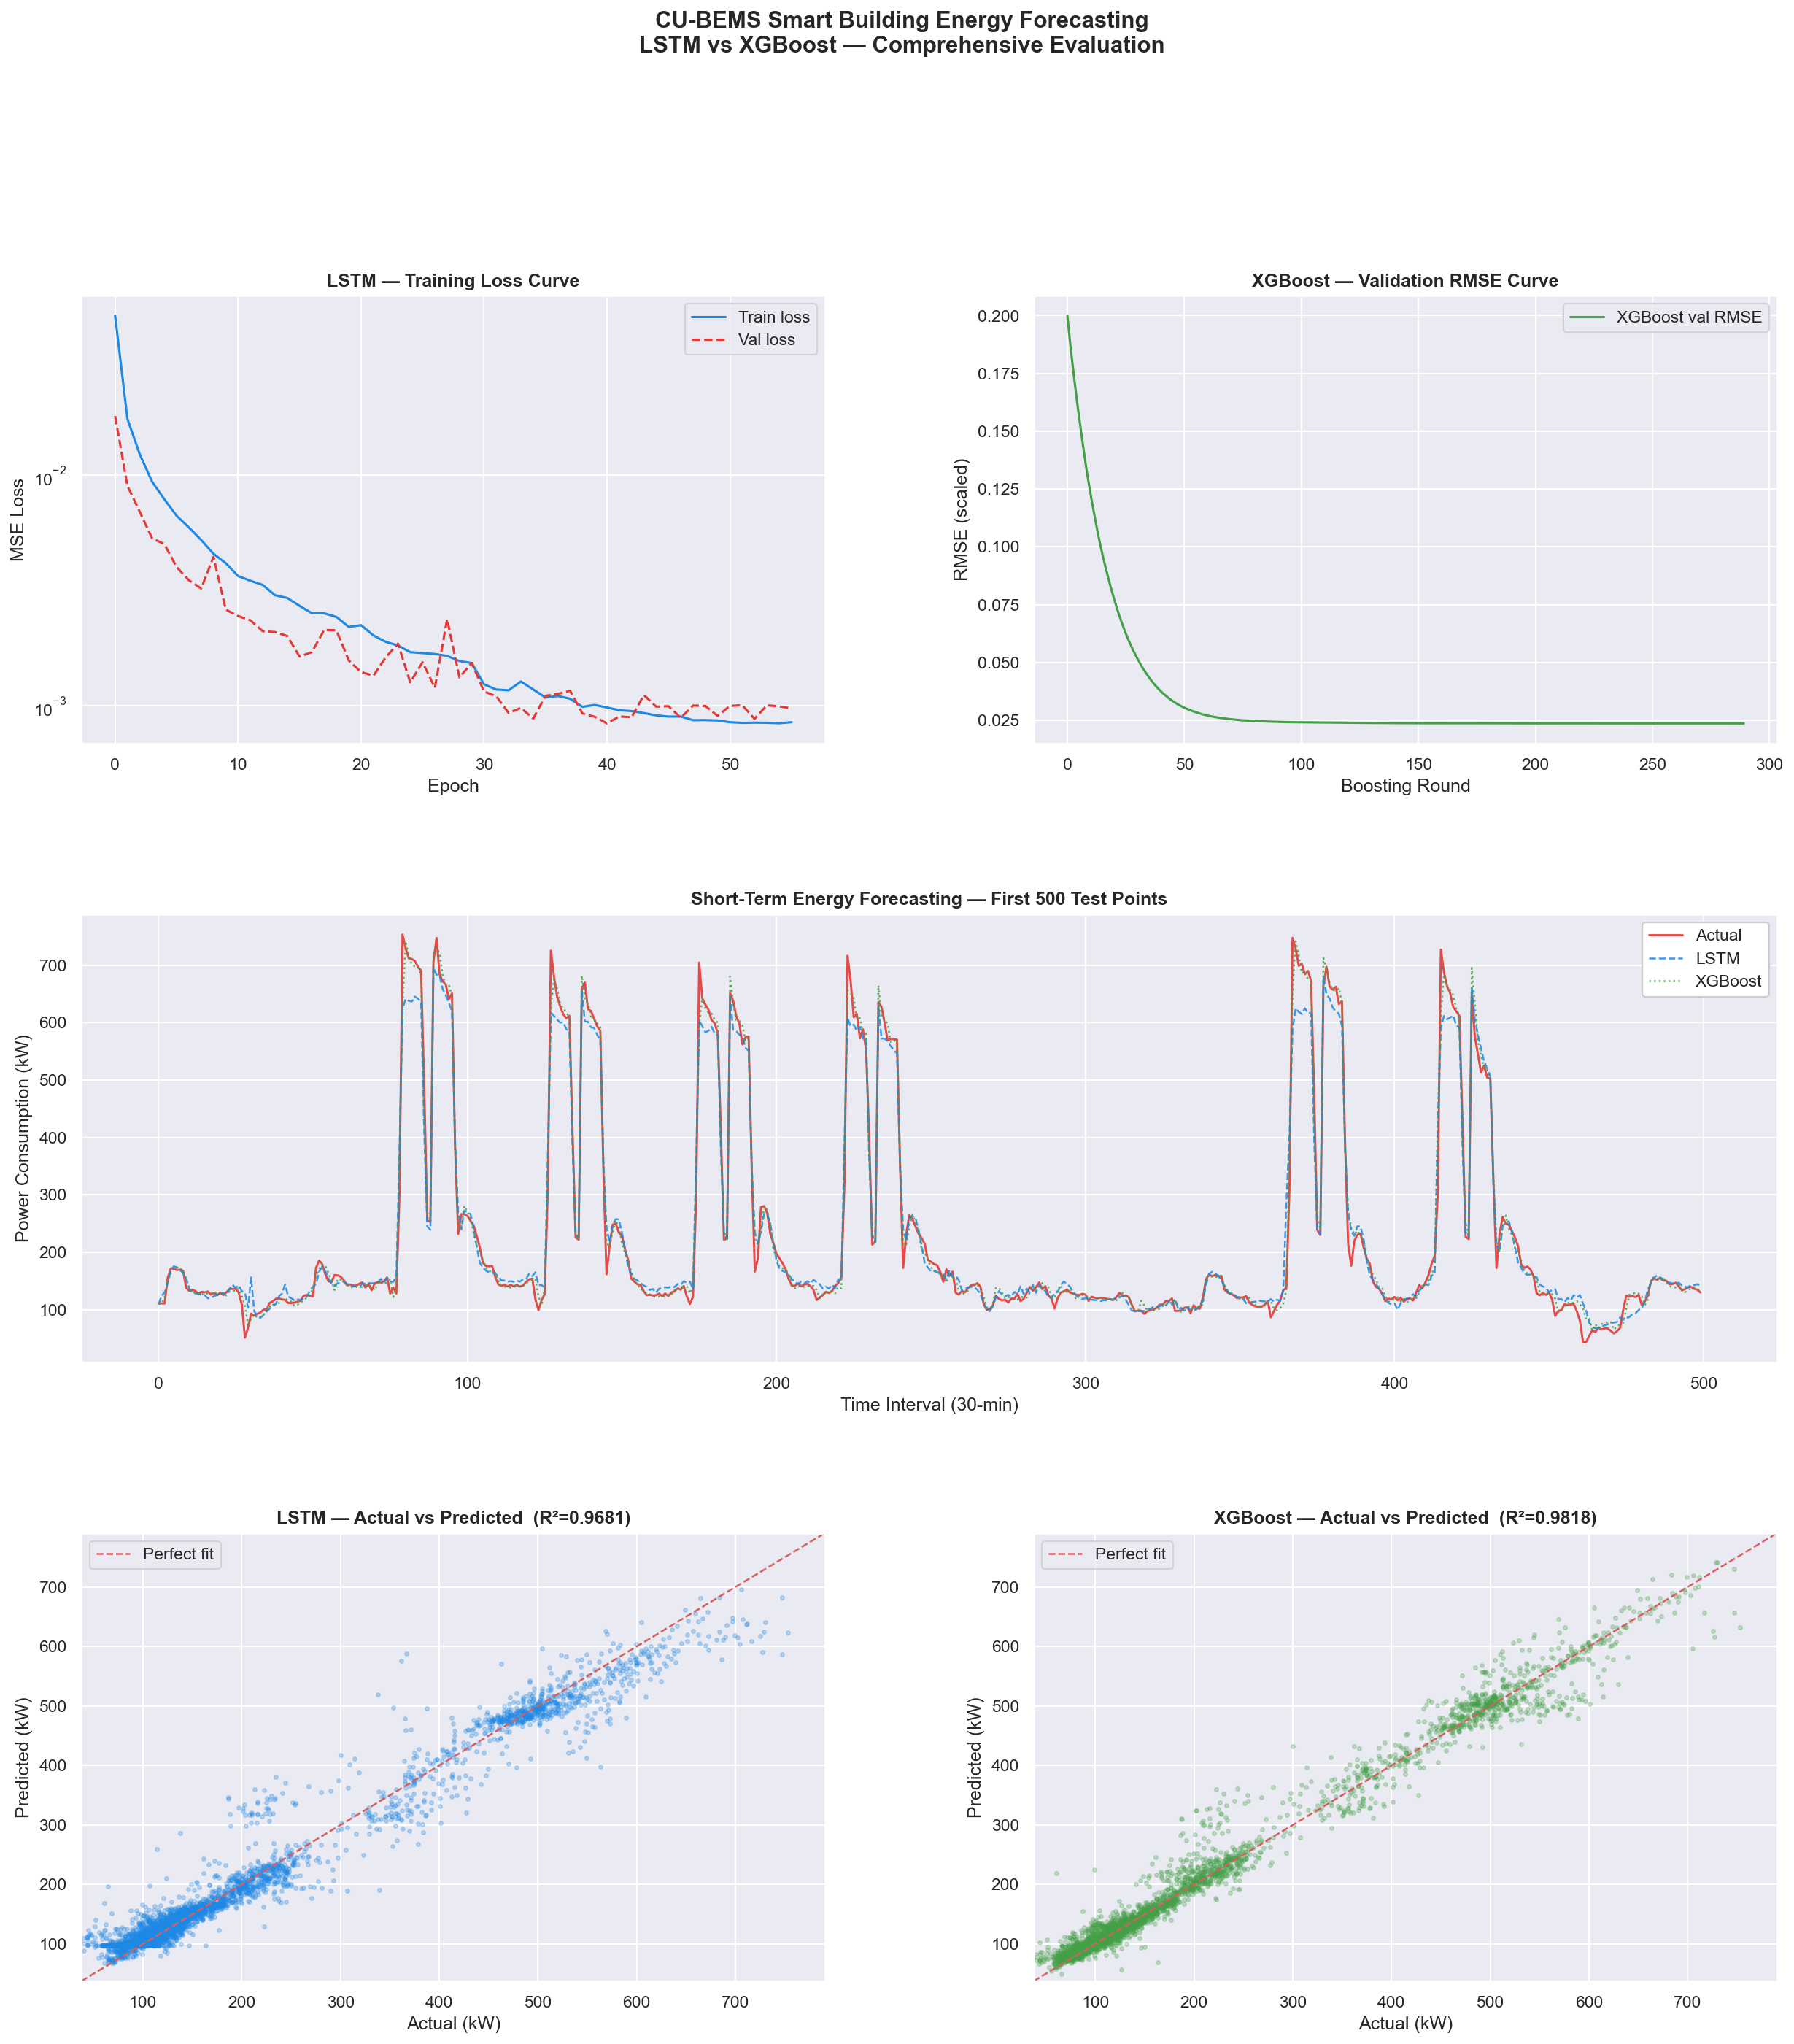

In [41]:
if not RETRAIN_LSTM and not RETRAIN_XGB and os.path.exists('../saved_fig/forecasting_comparison.png'):
    print('Models loaded from disk. Displaying previously saved visualization:')
    display(Image('../saved_fig/forecasting_comparison.png')) #load previous visualization because loaded models dont have learning history
else:
    PLOT_LEN = 500   # number of test-set points to show in time-series plot

    fig = plt.figure(figsize=(20, 20))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.38, wspace=0.28)

    # ── Panel 1: LSTM training curves ────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    if history_lstm is not None:
        ax1.plot(history_lstm.history['loss'],     label='Train loss',      color='#1E88E5')
        ax1.plot(history_lstm.history['val_loss'], label='Val loss',        color='#E53935', linestyle='--')
        ax1.legend(); ax1.set_yscale('log')
    else:
        ax1.text(0.5, 0.5, 'Training history not available\n(Model loaded from disk)', 
                 ha='center', va='center', color='gray', fontsize=12)
        ax1.set_xticks([]); ax1.set_yticks([])
    ax1.set_title('LSTM — Training Loss Curve', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE Loss')

    # ── Panel 2: XGBoost training curve ──────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    try:
        xgb_evals = xgb_final.evals_result()
        if xgb_evals:
            ax2.plot(xgb_evals['validation_0']['rmse'], color='#43A047', label='XGBoost val RMSE')
            ax2.legend()
        else:
            raise ValueError('Empty evals')
    except Exception:
        ax2.text(0.5, 0.5, 'Training history not available\n(Model loaded from disk)', 
                 ha='center', va='center', color='gray', fontsize=12)
        ax2.set_xticks([]); ax2.set_yticks([])
    ax2.set_title('XGBoost — Validation RMSE Curve', fontweight='bold')
    ax2.set_xlabel('Boosting Round'); ax2.set_ylabel('RMSE (scaled)')

    # ── Panel 3: Time-series prediction overlay ───────────────────────
    ax3 = fig.add_subplot(gs[1, :])
    ax3.plot(y_true_test[:PLOT_LEN],  label='Actual',   color='#E53935', linewidth=1.4, alpha=0.9)
    ax3.plot(y_pred_lstm[:PLOT_LEN],  label='LSTM',     color='#1E88E5', linewidth=1.2,
             linestyle='--', alpha=0.85)
    ax3.plot(y_pred_xgb[:PLOT_LEN],   label='XGBoost',  color='#43A047', linewidth=1.2,
             linestyle=':',  alpha=0.85)
    ax3.set_title(f'Short-Term Energy Forecasting — First {PLOT_LEN} Test Points',
                  fontweight='bold')
    ax3.set_xlabel('Time Interval (30-min)'); ax3.set_ylabel('Power Consumption (kW)')
    ax3.legend(frameon=True, facecolor='white', framealpha=1)

    # ── Panel 4: Scatter — LSTM ───────────────────────────────────────
    ax4 = fig.add_subplot(gs[2, 0])
    lim = (min(y_true_test.min(), y_pred_lstm.min()) * 0.95,
           max(y_true_test.max(), y_pred_lstm.max()) * 1.05)
    ax4.scatter(y_true_test, y_pred_lstm, alpha=0.25, s=6, color='#1E88E5')
    ax4.plot(lim, lim, 'r--', linewidth=1.2, label='Perfect fit')
    ax4.set_xlim(lim); ax4.set_ylim(lim)
    ax4.set_title(f'LSTM — Actual vs Predicted  (R²={lstm_test_metrics["R2"]:.4f})',
                  fontweight='bold')
    ax4.set_xlabel('Actual (kW)'); ax4.set_ylabel('Predicted (kW)')
    ax4.legend()

    # ── Panel 5: Scatter — XGBoost ───────────────────────────────────
    ax5 = fig.add_subplot(gs[2, 1])
    lim2 = (min(y_true_test.min(), y_pred_xgb.min()) * 0.95,
            max(y_true_test.max(), y_pred_xgb.max()) * 1.05)
    ax5.scatter(y_true_test, y_pred_xgb,  alpha=0.25, s=6, color='#43A047')
    ax5.plot(lim2, lim2, 'r--', linewidth=1.2, label='Perfect fit')
    ax5.set_xlim(lim2); ax5.set_ylim(lim2)
    ax5.set_title(f'XGBoost — Actual vs Predicted  (R²={xgb_test_metrics["R2"]:.4f})',
                  fontweight='bold')
    ax5.set_xlabel('Actual (kW)'); ax5.set_ylabel('Predicted (kW)')
    ax5.legend()

    plt.suptitle('CU-BEMS Smart Building Energy Forecasting\nLSTM vs XGBoost — Comprehensive Evaluation',
                 fontsize=15, fontweight='bold', y=1.01)
    
    if not RETRAIN_LSTM and not RETRAIN_XGB and os.path.exists("../saved_fig/forecasting_comparison.png"):
        plt.savefig('../saved_fig/forecasting_comparison.png', dpi=600, bbox_inches='tight')
    plt.show()


## 10. XGBoost Feature Importance

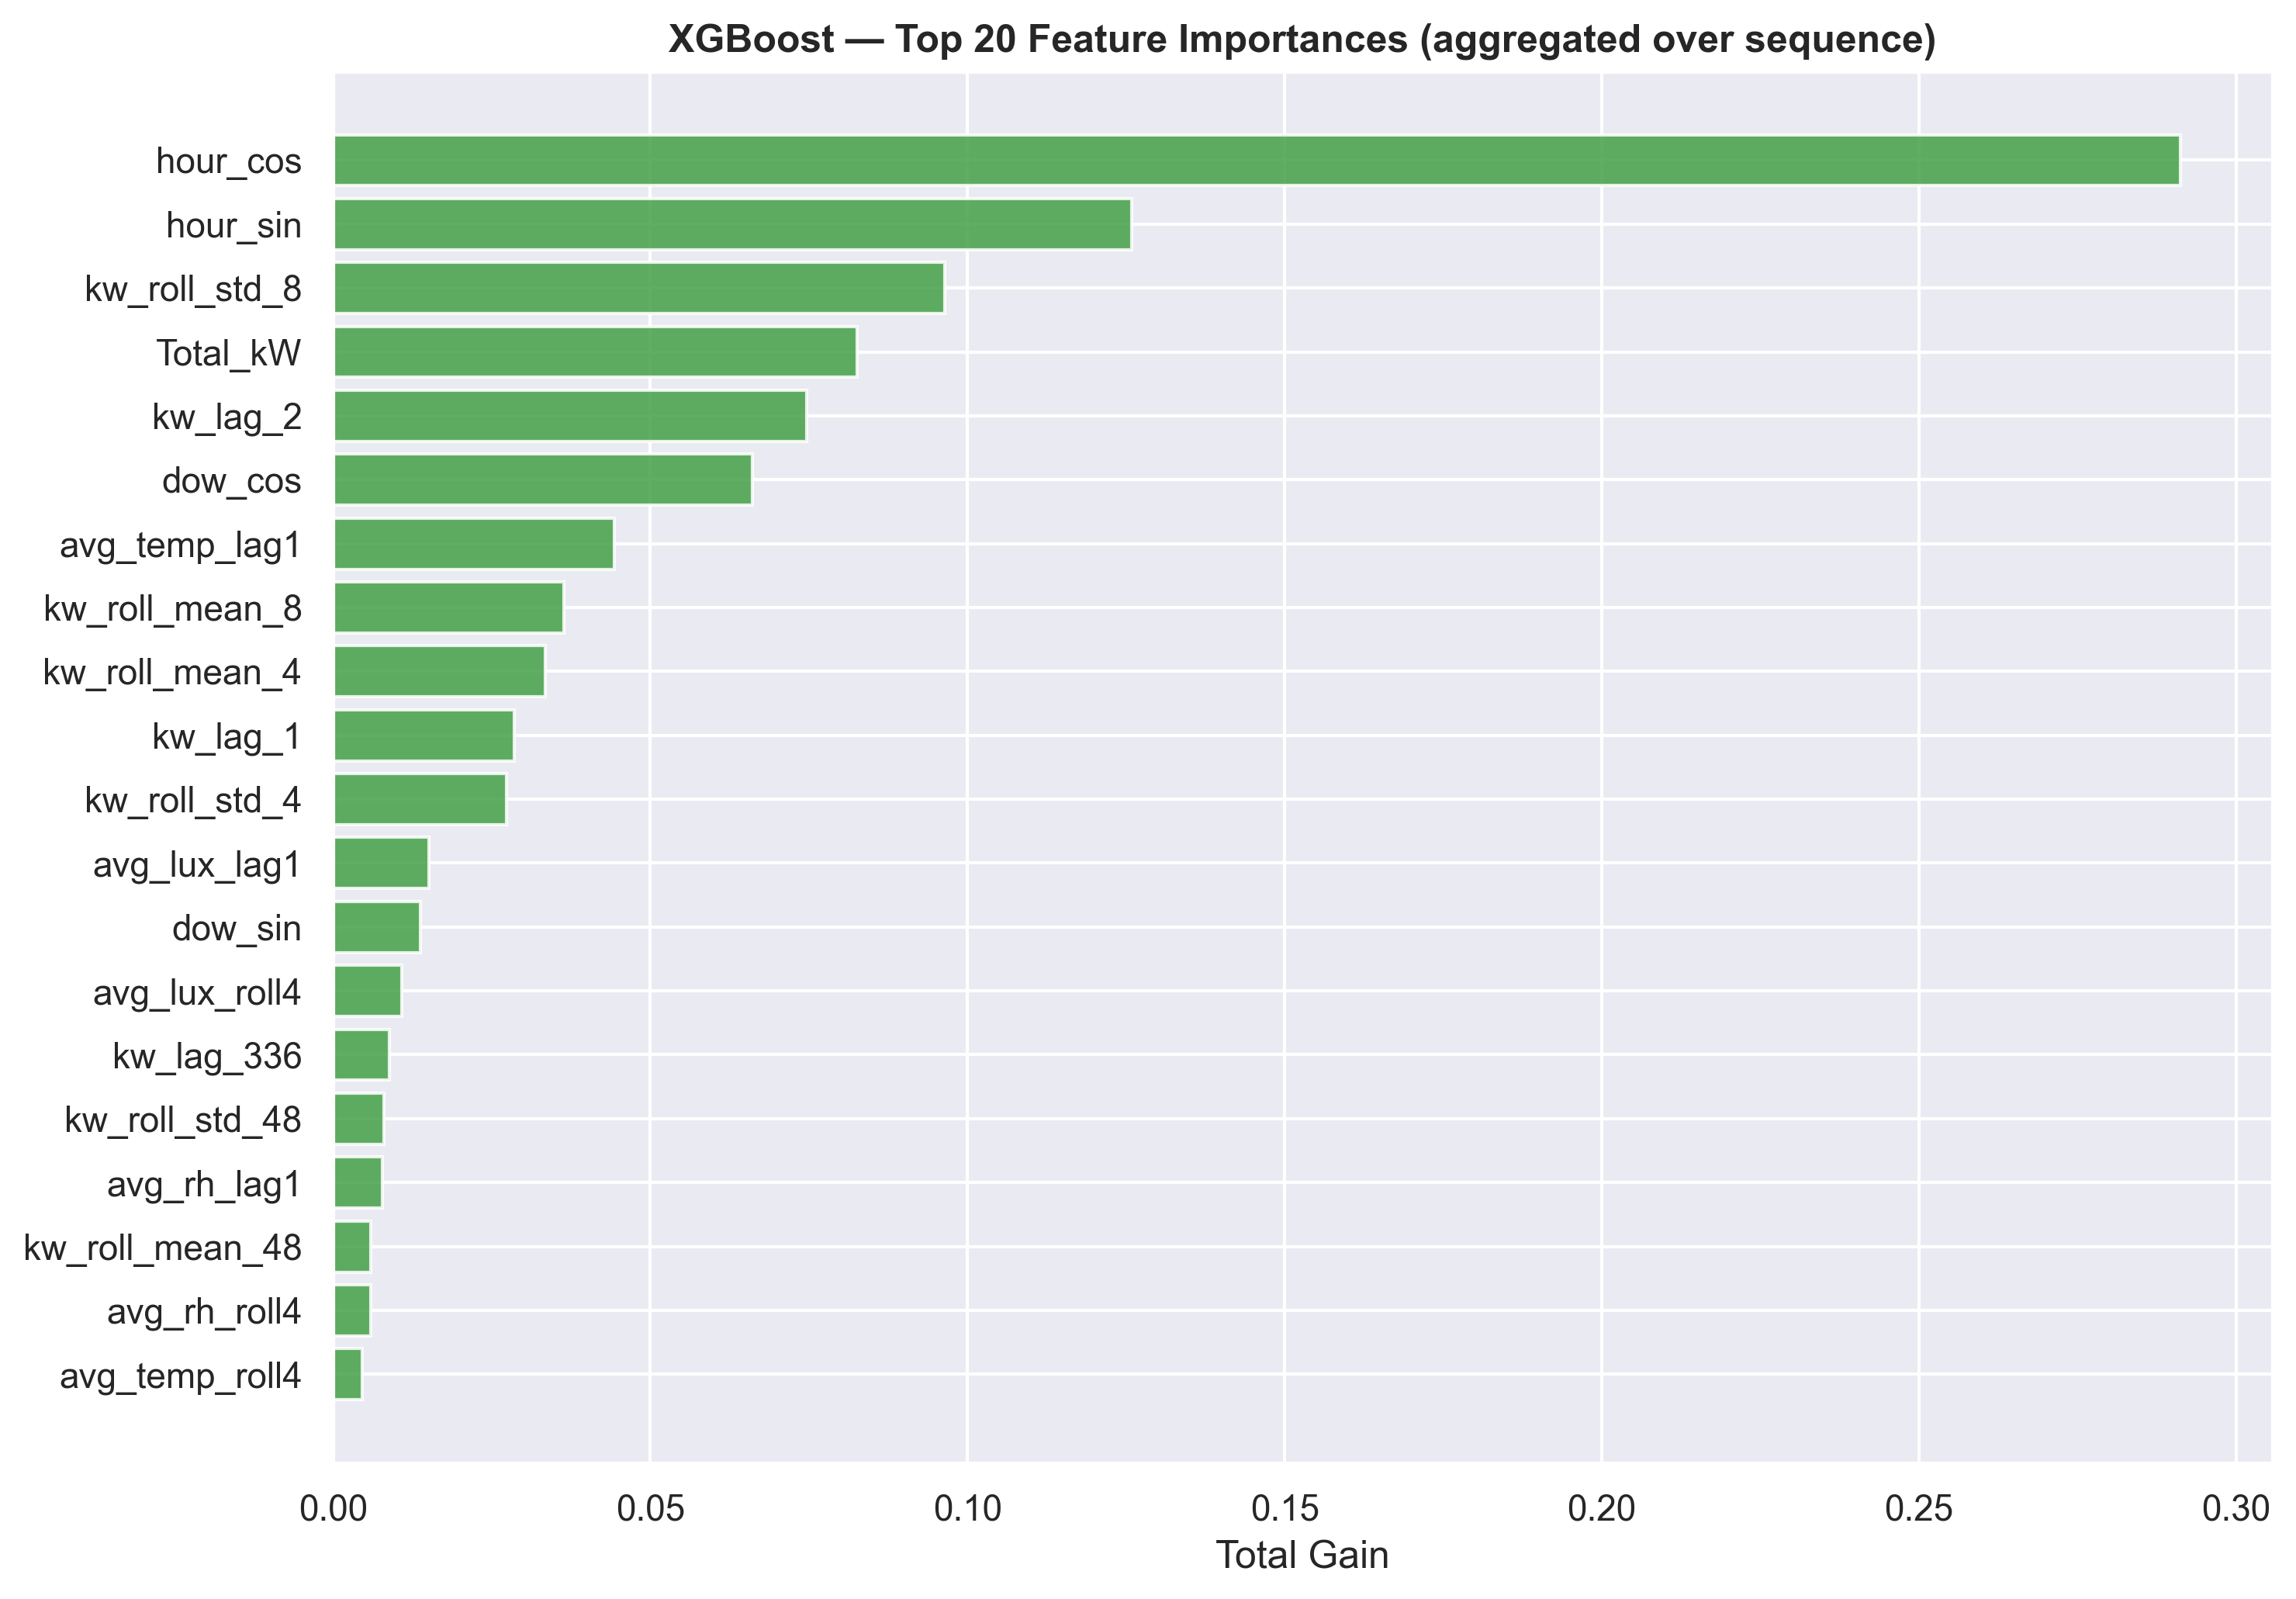

In [42]:
# XGBoost gives per-flat-feature importances.
raw_importance = pd.Series(xgb_final.feature_importances_)
n_features = X_tr.shape[2]          # number of engineered features
feat_names = df_fe.columns.tolist() # includes TARGET at target_idx

# Sum importances over all time-steps for each feature
importance_by_feature = np.zeros(n_features)
for flat_idx, imp in enumerate(raw_importance):
    feat_pos = flat_idx % n_features
    importance_by_feature[feat_pos] += imp

# Build a readable dataframe
feat_imp_df = pd.DataFrame({
    'Feature'   : feat_names,
    'Importance': importance_by_feature
}).sort_values('Importance', ascending=True)

# Plot top 20
top = feat_imp_df.tail(20)
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top['Feature'], top['Importance'],
               color='#43A047', edgecolor='white', alpha=0.85)
ax.set_title('XGBoost — Top 20 Feature Importances (aggregated over sequence)',
             fontweight='bold')
ax.set_xlabel('Total Gain')
plt.tight_layout()

if not RETRAIN_LSTM and not RETRAIN_XGB and os.path.exists("../saved_fig/feature_importance.png"):
    plt.savefig('../saved_fig/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


## 11. Residual Analysis

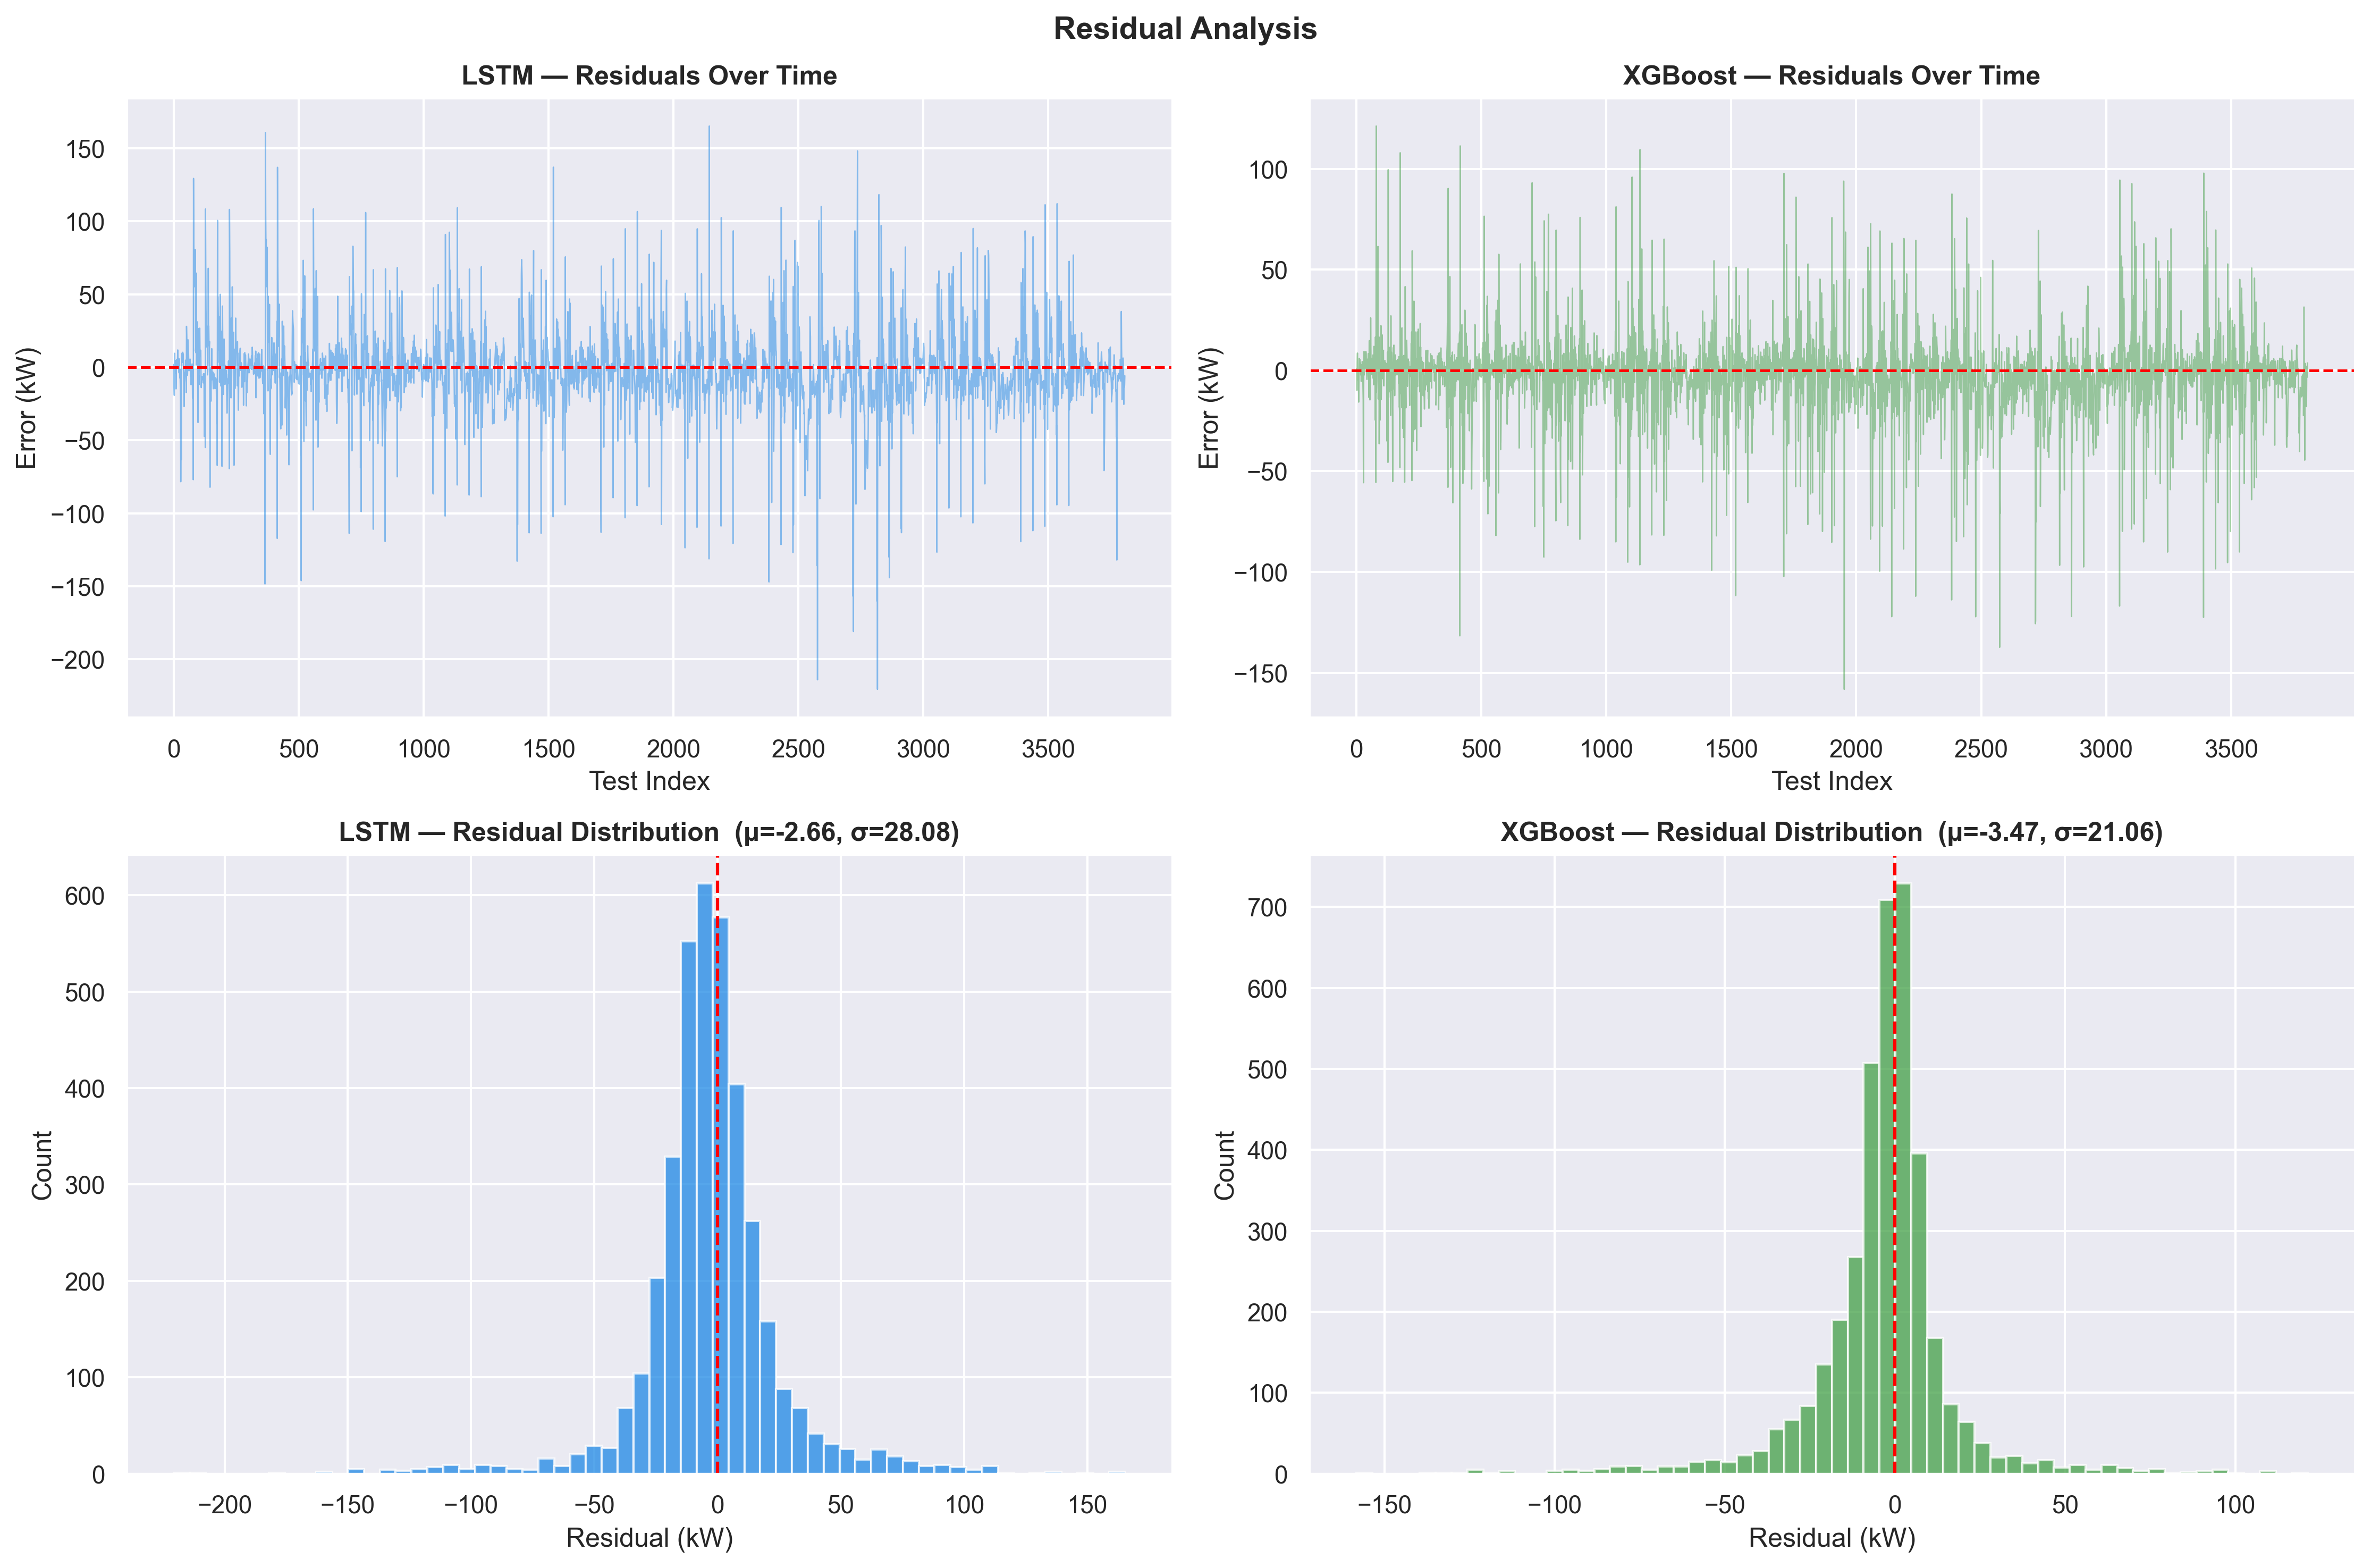

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for i, (name, y_pred) in enumerate([('LSTM', y_pred_lstm), ('XGBoost', y_pred_xgb)]):
    residuals = y_true_test - y_pred

    # Residuals over time
    axes[0, i].plot(residuals, color=['#1E88E5','#43A047'][i],
                    alpha=0.5, linewidth=0.6)
    axes[0, i].axhline(0, color='red', linewidth=1.2, linestyle='--')
    axes[0, i].set_title(f'{name} — Residuals Over Time', fontweight='bold')
    axes[0, i].set_xlabel('Test Index'); axes[0, i].set_ylabel('Error (kW)')

    # Residual distribution
    axes[1, i].hist(residuals, bins=60,
                    color=['#1E88E5','#43A047'][i], alpha=0.75, edgecolor='white')
    axes[1, i].axvline(0, color='red', linewidth=1.5, linestyle='--')
    axes[1, i].set_title(f'{name} — Residual Distribution  '
                          f'(μ={residuals.mean():.2f}, σ={residuals.std():.2f})',
                          fontweight='bold')
    axes[1, i].set_xlabel('Residual (kW)'); axes[1, i].set_ylabel('Count')

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()

if not RETRAIN_LSTM and not RETRAIN_XGB and os.path.exists("../saved_fig/residual_analysis.png"):
    plt.savefig('../saved_fig/residual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


## 12. Paper-Ready Summary Table

In [44]:
print('\n' + '='*74)
print('  PAPER RESULTS TABLE — CU-BEMS Smart Building Energy Forecasting')
print('='*74)

if not RETRAIN_LSTM and not RETRAIN_XGB and os.path.exists("./saved_cv/lstm_cv_metrics.csv") and os.path.exists("./saved_cv/xgb_cv_metrics.csv"):
    lstm_cv_df = pd.read_csv ("./saved_cv/lstm_cv_metrics.csv") #used when loading models only
    xgb_cv_df  = pd.read_csv ("./saved_cv/xgb_cv_metrics.csv")   #used when loading models only

print('\n  A. Cross-Validation (TimeSeriesSplit, 3 folds)')
print('  ' + '-'*56)
print(f'  {"Metric":<8}  {"LSTM mean±std":>22}  {"XGBoost mean±std":>24}')
for metric in ['RMSE', 'MAE', 'R2', 'SMAPE', 'NRMSE']:
    lv = f'{lstm_cv_df[metric].mean():.4f} ± {lstm_cv_df[metric].std():.4f}'
    xv = f'{xgb_cv_df[metric].mean():.4f} ± {xgb_cv_df[metric].std():.4f}'
    print(f'  {metric:<8}  {lv:>22}  {xv:>24}')

print('\n  B. Final Hold-Out Test Set (15%)')
print('  ' + '-'*56)
print(f'  {"Metric":<8}  {"LSTM":>12}  {"XGBoost":>14}  {"Naive":>12}')
naive_r2   = r2_score(naive_true, naive_pred)
naive_full = {**naive_metrics, 'R2': naive_r2}
for metric in ['RMSE', 'MAE', 'R2', 'SMAPE', 'NRMSE']:
    lv = lstm_test_metrics[metric]
    xv = xgb_test_metrics[metric]
    nv = naive_full[metric]
    print(f'  {metric:<8}  {lv:>12.4f}  {xv:>14.4f}  {nv:>12.4f}')

print('\n  C. Improvement over Naive Persistence')
print('  ' + '-'*56)
for model_name, m in [('LSTM', lstm_test_metrics), ('XGBoost', xgb_test_metrics)]:
    imp_mae  = (naive_full['MAE']  - m['MAE'])  / naive_full['MAE']  * 100
    imp_rmse = (naive_full['RMSE'] - m['RMSE']) / naive_full['RMSE'] * 100
    print(f'  {model_name:<10}  MAE improvement: {imp_mae:+.1f}%   RMSE improvement: {imp_rmse:+.1f}%')

print('='*74)



  PAPER RESULTS TABLE — CU-BEMS Smart Building Energy Forecasting

  A. Cross-Validation (TimeSeriesSplit, 3 folds)
  --------------------------------------------------------
  Metric             LSTM mean±std          XGBoost mean±std
  RMSE           48.1040 ± 30.8295          27.6479 ± 6.7840
  MAE            32.4744 ± 21.1455          16.3082 ± 3.5865
  R2               0.9002 ± 0.1260           0.9754 ± 0.0112
  SMAPE           14.5085 ± 7.6215           7.4955 ± 1.0452
  NRMSE            0.0614 ± 0.0420           0.0346 ± 0.0079

  B. Final Hold-Out Test Set (15%)
  --------------------------------------------------------
  Metric            LSTM         XGBoost         Naive
  RMSE           28.2108         21.3486       66.8446
  MAE            17.9291         12.6593       27.1841
  R2              0.9681          0.9818        0.8211
  SMAPE          10.5096          6.9534       11.0988
  NRMSE           0.0395          0.0299        0.0936

  C. Improvement over Naive Pers